# A Multi-Layer Perceptron from Scratch — MNIST Handwritten Digit Recognition

**UTS Machine Learning — Assignment A2 (Option 1: study a fundamental model)**

| | |
|---|---|
| Student | Bui Viet Duc Hoang |
| Student ID | 14517926 |
| Colab URL (paste as **plain text** in the journal PDF) | `TODO: https://colab.research.google.com/...` |

Forward pass, backpropagation and the optimizers (SGD, Momentum, Adam) below are implemented in
**NumPy only** — no `scikit-learn`, `torch`, `tensorflow` or `keras` anywhere, including for
metrics, splitting or data loading. This notebook is the complete, self-contained
implementation and evaluation; the problem definition, design rationale, results, discussion
and implementation log are in the accompanying report.

---
## 0. Environment and reproducibility

Self-contained per the specification: the only third-party imports are NumPy (arrays) and
Matplotlib (plots), both preinstalled in Colab. Everything else is the standard library.

In [1]:
# [complete] Environment. Installs nothing on Colab; the guard is for a bare local kernel.
import sys, subprocess, importlib

for pkg in ("numpy", "matplotlib"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        print("installing " + pkg + " ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import gzip
import hashlib
import os
import struct
import time
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Deliberately absent: sklearn, torch, tensorflow, keras. Option 1 requires that the model, the
# loss, the optimizers, the split and the metrics are all implemented in this notebook.
for banned in ("sklearn", "torch", "tensorflow", "keras"):
    assert banned not in sys.modules, banned + " was imported; Option 1 forbids off-the-shelf models"

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)

python      3.13.2
numpy       2.1.1
matplotlib  3.10.1


In [2]:
# [complete] Reproducibility. Everything stochastic (init, shuffling, dropout, family sampling)
# draws from a Generator passed in explicitly -- no reliance on global np.random state, so any
# result can be reproduced from its seed alone.
SEED = 20250909

def make_rng(seed: int = SEED) -> np.random.Generator:
    """Fresh PCG64 generator. Pass one explicitly into anything stochastic."""
    return np.random.default_rng(seed)

rng = make_rng()

# float64 throughout: the finite-difference check in 3.7 needs the precision, and at this model
# size float32 would not be the bottleneck anyway. Revisit if you scale the network up.
DTYPE = np.float64

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (6.0, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

print("seed", SEED, "| dtype", np.dtype(DTYPE).name)

seed 20250909 | dtype float64


---
## 1. Task definition (Criterion A)

Both training and deployment interfaces are specified below, since they differ: training
consumes a labelled batch, deployment consumes one unlabelled image.

### 1.1 Training-phase interface

| | Specification |
|---|---|
| **Input `X`** | `float64` array of shape `(N, 784)`. Each row is a 28×28 grayscale image flattened row-major, intensities rescaled from `uint8` 0–255 into `[0, 1]` by dividing by the constant 255 (not per-image min/max), so the transform is identical at deployment. Ink is high-valued: background 0.0, stroke centres near 1.0. |
| **Input `y`** | `int64` array of shape `(N,)` with values in `{0,…,9}`. |
| **Output** | `float64` array of shape `(N, 10)` of unnormalised logits; a row-wise softmax turns it into a probability distribution. |
| **Training objective** | Mean multi-class cross-entropy between the softmax of the logits and the one-hot labels (§3.5), minimised by mini-batch gradient descent (§4). |
| **Provenance** | MNIST (LeCun, Cortes, Burges), 60,000 training / 10,000 test images, written by **disjoint sets of writers**. |

### 1.2 Deployment-phase interface

| | Specification |
|---|---|
| **Input** | One `uint8` array of shape `(28, 28)`, values 0–255, ink-on-light-background. The wrapper in §8 validates dtype, shape and range and **rejects** anything else. |
| **Output** | `(label: int, confidence: float)` plus the full 10-vector. |
| **Out-of-scope input** | A non-digit input still yields a confident label (§8 demonstrates this); §7.5 adds a reject option as mitigation. |

### 1.4 A dummy classifier that matches the signature

Specification §7.1 asks for a function with the right type signature *before* any learning, tested
on real data even though the results will be poor. It earns its place: it sets the floor any
learned model must clear, and it converts §1.3's claim that "rules are insufficient" into a
measurement.

In [3]:
# [complete] Two non-learned baselines, both honouring the deployment signature from 1.2.
def classify_digit_constant(image: np.ndarray) -> Tuple[int, float]:
    """Always predicts the most frequent training class. The true floor: a model that cannot beat
    this has learned nothing. Its accuracy is the majority-class prior (~11.2% on MNIST)."""
    return 1, 0.1124  # class 1 is the plurality in the MNIST training split

def classify_digit_by_ink(image: np.ndarray) -> Tuple[int, float]:
    """A hand-written rule over total ink, vertical ink distribution and a stroke-width proxy --
    the kind of feature engineering the pre-learning literature relied on. It is deliberately
    naive; its failure is the argument for learning the features instead of designing them."""
    x = image.astype(np.float64) / 255.0
    ink = x.sum()
    top_heavy = x[:14].sum() / max(ink, 1e-9)
    width = (x > 0.5).sum() / max((x > 0.05).sum(), 1)
    # Thresholds eyeballed from a handful of examples -- that arbitrariness is the point.
    if ink < 70:
        return 1, 0.20
    if ink > 155:
        return 0, 0.20
    if top_heavy > 0.62:
        return 7, 0.15
    if width > 0.72:
        return 8, 0.15
    return 3, 0.10

print("Signatures defined; 2.3 scores them once the data is loaded.")

Signatures defined; 2.3 scores them once the data is loaded.


---
## 2. Data pipeline

Self-contained per the specification: this section downloads MNIST over the network, verifies it
byte-for-byte, parses the IDX binary format by hand and builds the splits. Nothing is assumed to be
on disk, and no dataset-loader library is used.

Two mirrors are tried in order — the original host at `yann.lecun.com` now returns 404, so the
notebook cannot depend on it. Each file is checked against a SHA-256 digest recorded when this
notebook was written: if a mirror ever serves altered bytes the run stops, rather than training on
silently different data.

In [4]:
# [complete] Download with mirror fallback and integrity verification.
DATA_DIR = Path("data_mnist")

MIRRORS = (
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
)

# SHA-256 of the gzipped files, cross-checked against both mirrors on 2026-09-09.
CHECKSUMS = {
    "train-images-idx3-ubyte.gz": "440fcabf73cc546fa21475e81ea370265605f56be210a4024d2ca8f203523609",
    "train-labels-idx1-ubyte.gz": "3552534a0a558bbed6aed32b30c495cca23d567ec52cac8be1a0730e8010255c",
    "t10k-images-idx3-ubyte.gz":  "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6",
    "t10k-labels-idx1-ubyte.gz":  "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6",
}

def _sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def fetch(filename: str, data_dir: Path = DATA_DIR) -> Path:
    """Download `filename` if absent, then verify its digest. Idempotent, safe to re-run."""
    data_dir.mkdir(parents=True, exist_ok=True)
    dest = data_dir / filename

    if dest.exists() and _sha256(dest) == CHECKSUMS[filename]:
        return dest

    errors = []
    for base in MIRRORS:
        try:
            req = urllib.request.Request(base + filename, headers={"User-Agent": "Mozilla/5.0"})
            t0 = time.time()
            with urllib.request.urlopen(req, timeout=120) as r:
                payload = r.read()
            dest.write_bytes(payload)
            got = _sha256(dest)
            if got != CHECKSUMS[filename]:
                dest.unlink(missing_ok=True)
                errors.append(base + ": checksum mismatch (got " + got[:12] + "...)")
                continue
            print("  %-32s %5.1f MB  %4.1fs  verified" % (filename, len(payload) / 1e6, time.time() - t0))
            return dest
        except Exception as e:
            errors.append(base + ": " + type(e).__name__ + ": " + str(e))

    raise RuntimeError("could not fetch " + filename + "\n  " + "\n  ".join(errors))

print("Fetching MNIST ...")
paths = {name: fetch(name) for name in CHECKSUMS}
print("All four files present and verified.")

Fetching MNIST ...
All four files present and verified.


In [5]:
# [complete] IDX parser. The format is a 4-byte magic number (0x00 00 TT DD -- TT is the element
# type, DD the number of dimensions), then DD big-endian int32 dimension sizes, then raw bytes.
# Parsing it by hand rather than calling a loader keeps the pipeline auditable, and it is 12 lines.
def read_idx(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic = f.read(4)
        if magic[:2] != b"\x00\x00":
            raise ValueError(path.name + ": bad IDX magic " + repr(magic))
        type_code, n_dims = magic[2], magic[3]
        if type_code != 0x08:
            raise ValueError(path.name + ": expected a uint8 payload, got type code " + hex(type_code))
        shape = struct.unpack(">" + str(n_dims) + "I", f.read(4 * n_dims))
        buf = f.read()
        expected = int(np.prod(shape))
        if len(buf) != expected:
            raise ValueError(path.name + ": expected " + str(expected) + " bytes, read " + str(len(buf)))
        return np.frombuffer(buf, dtype=np.uint8).reshape(shape)

train_images_u8 = read_idx(paths["train-images-idx3-ubyte.gz"])          # (60000, 28, 28) uint8
train_labels    = read_idx(paths["train-labels-idx1-ubyte.gz"]).astype(np.int64)
test_images_u8  = read_idx(paths["t10k-images-idx3-ubyte.gz"])           # (10000, 28, 28) uint8
test_labels     = read_idx(paths["t10k-labels-idx1-ubyte.gz"]).astype(np.int64)

# These assertions restate the 1.1 contract, and would catch a mirror serving the files reordered.
assert train_images_u8.shape == (60000, 28, 28) and train_labels.shape == (60000,)
assert test_images_u8.shape == (10000, 28, 28) and test_labels.shape == (10000,)
assert train_images_u8.dtype == np.uint8 and train_images_u8.max() == 255
assert set(np.unique(train_labels)) == set(range(10))

N_CLASSES = 10
IMAGE_SHAPE = (28, 28)
N_FEATURES = int(np.prod(IMAGE_SHAPE))  # 784

print("train images", train_images_u8.shape, train_images_u8.dtype)
print("test  images", test_images_u8.shape, test_images_u8.dtype)
print("train class counts", np.bincount(train_labels))
print("test  class counts", np.bincount(test_labels))
print("majority-class prior (train): %.4f" % (np.bincount(train_labels).max() / len(train_labels)))

train images (60000, 28, 28) uint8
test  images (10000, 28, 28) uint8


train class counts [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
test  class counts [ 980 1135 1032 1010  982  892  958 1028  974 1009]
majority-class prior (train): 0.1124


### 2.1 Validation scheme

Three splits: **train** (50,000, parameter updates), **validation** (10,000, carved from the
official 60k training file — every hyperparameter choice is made here), **test** (the official
10k test file, reported once). Validation is drawn from the training file rather than the test
file so the only writer-disjoint split (§1.1) stays untouched until the final number.

In [6]:
# [complete] Preprocessing and splits.
def preprocess(images_u8: np.ndarray) -> np.ndarray:
    """uint8 (n, 28, 28) in 0..255  ->  float64 (n, 784) in [0, 1].

    Division by the global constant 255 -- not per-image min/max -- so the mapping is fixed,
    identical at training and deployment, and independent of any batch. Exactly the transform
    declared in the 1.1 interface.
    """
    return images_u8.reshape(len(images_u8), -1).astype(DTYPE) / 255.0

def one_hot(y: np.ndarray, n_classes: int = N_CLASSES) -> np.ndarray:
    """(n,) integer labels -> (n, n_classes) float64 indicator rows."""
    out = np.zeros((len(y), n_classes), dtype=DTYPE)
    out[np.arange(len(y)), y] = 1.0
    return out

N_VAL = 10_000
_perm = make_rng(SEED).permutation(len(train_images_u8))
_val_idx, _train_idx = _perm[:N_VAL], _perm[N_VAL:]

X_train, y_train = preprocess(train_images_u8[_train_idx]), train_labels[_train_idx]
X_val,   y_val   = preprocess(train_images_u8[_val_idx]),   train_labels[_val_idx]
X_test,  y_test  = preprocess(test_images_u8),              test_labels

# Raw uint8 kept for the deployment demo in 8 and the error gallery in 7.2.
raw_val_images, raw_test_images = train_images_u8[_val_idx], test_images_u8

assert X_train.shape == (50_000, N_FEATURES) and X_val.shape == (N_VAL, N_FEATURES)
assert X_test.shape == (10_000, N_FEATURES)
assert 0.0 <= X_train.min() and X_train.max() <= 1.0
# No leakage: the two index sets are disjoint and together cover the training file exactly.
assert len(set(_train_idx.tolist()) & set(_val_idx.tolist())) == 0
assert len(set(_train_idx.tolist()) | set(_val_idx.tolist())) == len(train_images_u8)

for name, X, y in (("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)):
    print("%-6s X %-14s y %-10s mean px %.4f  min class share %.4f" %
          (name, str(X.shape), str(y.shape), X.mean(),
           (np.bincount(y, minlength=10) / len(y)).min()))

train  X (50000, 784)   y (50000,)   mean px 0.1307  min class share 0.0916
val    X (10000, 784)   y (10000,)   mean px 0.1302  min class share 0.0842
test   X (10000, 784)   y (10000,)   mean px 0.1325  min class share 0.0892


### 2.2 A look at the inputs

One figure, to confirm the pipeline produces what §1.1 claims. The specification warns that padding
a presentation with exploratory data analysis costs marks and invites questions about material you
never needed — so this is a correctness check, not an EDA section.

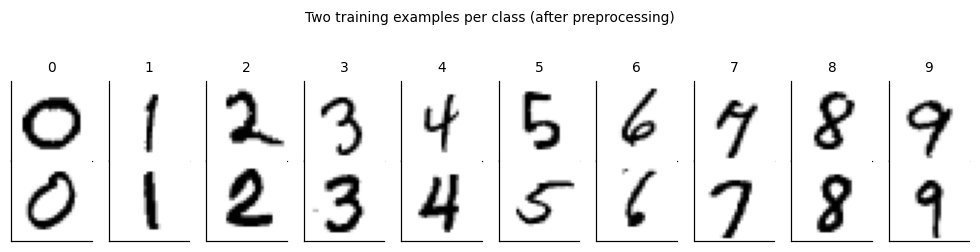

In [7]:
# [complete] Two examples per class, after preprocessing.
fig, axes = plt.subplots(2, 10, figsize=(9, 2.1))
for c in range(10):
    idx = np.flatnonzero(y_train == c)[:2]
    for r in range(2):
        ax = axes[r, c]
        ax.imshow(X_train[idx[r]].reshape(IMAGE_SHAPE), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0:
            ax.set_title(str(c), fontsize=9)
fig.suptitle("Two training examples per class (after preprocessing)", y=1.06, fontsize=9)
plt.tight_layout(); plt.show()

### 2.3 The baseline floor

Scoring §1.4's rule-based classifiers now. Whatever the trained network reaches in §7 has to be read
against these numbers — the gap between them is the empirical content of §1.3's motivation.

In [8]:
# [complete] Score the non-learned baselines on the validation split.
def evaluate_callable(fn: Callable[[np.ndarray], Tuple[int, float]],
                      images_u8: np.ndarray, y: np.ndarray, limit: int = 2000) -> float:
    """Accuracy of any function honouring the 1.2 deployment signature. `limit` keeps the Python
    loop quick -- these baselines are not vectorised, and 2000 samples pin the value to ~1%."""
    n = min(limit, len(y))
    preds = np.array([fn(images_u8[i])[0] for i in range(n)])
    return float((preds == y[:n]).mean())

acc_const = evaluate_callable(classify_digit_constant, raw_val_images, y_val)
acc_ink   = evaluate_callable(classify_digit_by_ink,   raw_val_images, y_val)

print("chance (uniform)          : %.4f" % (1 / N_CLASSES))
print("constant (majority class) : %.4f" % acc_const)
print("hand-written ink rules    : %.4f" % acc_ink)

chance (uniform)          : 0.1000
constant (majority class) : 0.1205
hand-written ink rules    : 0.1970


---
## 3. The model, component by component (Criterion B)

### 3.1 The hypothesis space

An $L$-layer MLP with parameters $\theta$ computes, from input $x \in \mathbb{R}^{784}$:

$$
a^{(0)} = x, \qquad
z^{(l)} = W^{(l)\top} a^{(l-1)} + b^{(l)}, \qquad
a^{(l)} = \phi\!\left(z^{(l)}\right) \quad (l = 1 \dots L-1), \qquad
f_\theta(x) = z^{(L)}
$$

$$
\mathcal{H} = \left\{\, f_\theta : \mathbb{R}^{784} \to \mathbb{R}^{10} \;\middle|\;
\theta = \left(W^{(1)}, b^{(1)}, \dots, W^{(L)}, b^{(L)}\right) \in \mathbb{R}^{d} \,\right\}
$$

For `[784, 256, 128, 10]`, $d = 235{,}146$. §5 samples from $\mathcal{H}$ before any training.

**Batching convention.** $X \in \mathbb{R}^{N \times d_{\text{in}}}$, $W \in \mathbb{R}^{d_{\text{in}}
\times d_{\text{out}}}$: the layer computes $Z = XW + b$, $b$ broadcast across rows.

### Module interface

| Method | Contract |
|---|---|
| `forward(X, training=True)` | returns this layer's output; caches whatever `backward` will need |
| `backward(dOut)` | given $\partial \mathcal{L}/\partial(\text{output})$, returns $\partial \mathcal{L}/\partial(\text{input})$, stores parameter gradients |
| `parameters()` | list of arrays, mutated **in place** by the optimizer |
| `gradients()` | list of arrays, aligned elementwise with `parameters()` |

In [9]:
# [complete] Base class. Defines the contract; the subclasses below fill it in.
class Module:
    """A component of the network. Stateless by default."""

    def forward(self, X: np.ndarray, training: bool = True) -> np.ndarray:
        raise NotImplementedError

    def backward(self, dOut: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def parameters(self) -> List[np.ndarray]:
        return []

    def gradients(self) -> List[np.ndarray]:
        return []

    def __repr__(self) -> str:
        return self.__class__.__name__ + "()"

### 3.2 `Dense` — the affine layer

**Forward.** $Z = XW + b$. **Backward**, given $\delta = \partial\mathcal{L}/\partial Z$:

$$
\frac{\partial \mathcal{L}}{\partial W} = X^\top \delta, \qquad
\frac{\partial \mathcal{L}}{\partial b} = \sum_{i=1}^{N} \delta_i, \qquad
\frac{\partial \mathcal{L}}{\partial X} = \delta W^\top
$$

No extra $1/N$ here — §3.5's loss already carries it. $b$'s gradient is a **sum** over the
batch, not a mean (broadcast's adjoint is "add up"). $L^2$ adds $\lambda W$ to `dW`, weights
only, never biases. Init: He ($\sigma=\sqrt{2/d_{\text{in}}}$) for ReLU, Xavier
($\sigma=\sqrt{2/(d_{\text{in}}+d_{\text{out}})}$) for symmetric activations — ablated in §7.4.

In [10]:
class Dense(Module):
    """Fully connected affine layer: Z = XW + b."""

    def __init__(self, d_in: int, d_out: int, rng: np.random.Generator,
                 init: str = "he", l2: float = 0.0):
        self.d_in, self.d_out, self.l2 = d_in, d_out, l2

        # [complete] Initialisation. Zero weights would make every unit in a layer compute the
        # same thing and receive the same gradient forever -- symmetry the network can never break.
        # The scale matters as much as the randomness: too large saturates, too small vanishes.
        if init == "he":
            std = np.sqrt(2.0 / d_in)
        elif init == "xavier":
            std = np.sqrt(2.0 / (d_in + d_out))
        elif init == "lecun":
            std = np.sqrt(1.0 / d_in)
        else:
            raise ValueError("unknown init: " + init)

        self.W = (rng.normal(0.0, std, size=(d_in, d_out))).astype(DTYPE)
        self.b = np.zeros(d_out, dtype=DTYPE)   # biases start at zero: no symmetry to break
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._X: Optional[np.ndarray] = None

    def forward(self, X: np.ndarray, training: bool = True) -> np.ndarray:
        self._X = X
        return X @ self.W + self.b

    def backward(self, dZ: np.ndarray) -> np.ndarray:
        self.dW[...] = self._X.T @ dZ + self.l2 * self.W
        self.db[...] = dZ.sum(axis=0)
        return dZ @ self.W.T

    def parameters(self) -> List[np.ndarray]:
        return [self.W, self.b]

    def gradients(self) -> List[np.ndarray]:
        return [self.dW, self.db]

    def l2_penalty(self) -> float:
        """The term this layer contributes to the reported loss (not to the gradient)."""
        return 0.5 * self.l2 * float(np.sum(self.W ** 2))

    def __repr__(self) -> str:
        return "Dense(%d -> %d, l2=%g)" % (self.d_in, self.d_out, self.l2)

### 3.3 `ReLU`

$$
\phi(z) = \max(0, z), \qquad
\frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a} \odot \mathbb{1}[z > 0]
$$

Gates on the **pre-activation** $z$ (cached in `forward`), not the output — matters once an
activation's output sign no longer determines its slope. Without $\phi$, composed affine layers
collapse to one affine map, so depth would buy nothing.

In [11]:
class ReLU(Module):
    """Elementwise rectifier."""

    def __init__(self):
        self._Z: Optional[np.ndarray] = None

    def forward(self, Z: np.ndarray, training: bool = True) -> np.ndarray:
        self._Z = Z
        return np.maximum(Z, 0)

    def backward(self, dA: np.ndarray) -> np.ndarray:
        return dA * (self._Z > 0)


class Tanh(Module):
    """[complete] Alternative activation, for the 7.4 ablation. a = tanh(z); da/dz = 1 - a^2.

    Provided so the ablation has something to compare against -- and note the derivative is written
    in terms of the *output*, which is why this class caches A rather than Z.
    """

    def __init__(self):
        self._A: Optional[np.ndarray] = None

    def forward(self, Z: np.ndarray, training: bool = True) -> np.ndarray:
        self._A = np.tanh(Z)
        return self._A

    def backward(self, dA: np.ndarray) -> np.ndarray:
        return dA * (1.0 - self._A ** 2)

### 3.4 `Dropout` (optional; used only in the §7.4 ablation)

Inverted dropout, keep probability $q=1-p$: $\tilde a = a \cdot m/q$, $m_{ij}\sim\text{Bernoulli}(q)$.
Identity at test time. The $1/q$ scaling keeps $\mathbb{E}[\tilde a] = a$ so activation
statistics don't shift between training and deployment.

In [12]:
class Dropout(Module):
    """Inverted dropout. Identity when training=False, or when p == 0."""

    def __init__(self, p: float, rng: np.random.Generator):
        if not 0.0 <= p < 1.0:
            raise ValueError("dropout p must be in [0, 1)")
        self.p, self.rng = p, rng
        self._mask: Optional[np.ndarray] = None

    def forward(self, A: np.ndarray, training: bool = True) -> np.ndarray:
        if (not training) or self.p == 0.0:
            self._mask = None
            return A
        q = 1.0 - self.p
        self._mask = (self.rng.random(A.shape) < q).astype(A.dtype) / q
        return A * self._mask

    def backward(self, dOut: np.ndarray) -> np.ndarray:
        if self._mask is None:
            return dOut
        return dOut * self._mask

    def __repr__(self) -> str:
        return "Dropout(p=%g)" % self.p

### 3.5 Softmax cross-entropy

$$
\mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log p_{i, y_i}, \qquad p_c = \frac{\exp(z_c)}{\sum_k\exp(z_k)}
$$

**Stability:** compute `log_softmax` directly via the max-shift identity —

$$
\log p_c = (z_c - m) - \log\!\sum_k \exp(z_k - m), \qquad m = \max_k z_k
$$

— never `log(softmax(z))`, which overflows/underflows on exactly the inputs this identity is
for. **Fused gradient:**

$$
\frac{\partial \mathcal{L}}{\partial z_{ic}} = \frac{1}{N}\left(p_{ic} - Y_{ic}\right)
$$

One subtraction, no softmax Jacobian — be ready to derive this live. With one-hot $Y$, minimising
cross-entropy is exactly minimising $D_{\mathrm{KL}}(Y\|\hat Q)$; the shared $\sum_c p_c=1$
constraint couples the outputs, unlike an independent per-output regression loss.

In [13]:
def log_softmax(logits: np.ndarray) -> np.ndarray:
    """Row-wise log-softmax, computed stably. logits (N, C) -> (N, C)."""
    m = np.max(logits, axis=1, keepdims=True)
    shifted = logits - m
    return shifted - np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))


def softmax(logits: np.ndarray) -> np.ndarray:
    """Row-wise softmax. logits (N, C) -> (N, C), rows summing to 1."""
    return np.exp(log_softmax(logits))


class SoftmaxCrossEntropy:
    """Fused softmax + mean cross-entropy. Not a Module: it sits at the end of the network and its
    backward() takes no incoming gradient, because it *is* the start of the chain."""

    def __init__(self):
        self._log_p: Optional[np.ndarray] = None
        self._y: Optional[np.ndarray] = None

    def forward(self, logits: np.ndarray, y: np.ndarray) -> float:
        """logits (N, C), y (N,) int labels -> scalar mean cross-entropy in nats."""
        self._log_p = log_softmax(logits)
        self._y = y
        return float(-np.mean(self._log_p[np.arange(len(y)), y]))

    def backward(self) -> np.ndarray:
        """dL/d(logits), shape (N, C). Must include the 1/N from the mean."""
        N = len(self._y)
        P = np.exp(self._log_p)
        P[np.arange(N), self._y] -= 1.0
        return P / N

### 3.6 `MLP`

Forward walks `self.layers` in order; backward walks the same list in reverse, threading the
gradient through. That reversal is backpropagation — reverse-mode autodiff specialised to a
chain. The final `Dense` emits logits with no activation after it; softmax lives in the loss.

In [14]:
class MLP:
    """Feed-forward network: Dense -> activation -> (Dropout) -> ... -> Dense (logits out)."""

    def __init__(self, layer_sizes: Sequence[int], rng: np.random.Generator,
                 activation: str = "relu", init: str = "he",
                 l2: float = 0.0, dropout: float = 0.0):
        if len(layer_sizes) < 2:
            raise ValueError("need at least an input and an output size")
        self.layer_sizes = list(layer_sizes)
        self.config = dict(layer_sizes=list(layer_sizes), activation=activation,
                           init=init, l2=l2, dropout=dropout)

        act_cls = {"relu": ReLU, "tanh": Tanh}[activation]

        # [complete] Build the chain. The final Dense has no activation after it: it emits logits,
        # and the nonlinearity that would go there (softmax) lives in the loss instead -- see 3.5.
        self.layers: List[Module] = []
        for i in range(len(layer_sizes) - 1):
            is_last = (i == len(layer_sizes) - 2)
            self.layers.append(Dense(layer_sizes[i], layer_sizes[i + 1], rng, init=init, l2=l2))
            if not is_last:
                self.layers.append(act_cls())
                if dropout > 0.0:
                    self.layers.append(Dropout(dropout, rng))

    # ---- the two passes -------------------------------------------------
    def forward(self, X: np.ndarray, training: bool = True) -> np.ndarray:
        """X (N, d_in) -> logits (N, n_classes)."""
        for layer in self.layers:
            X = layer.forward(X, training=training)
        return X

    def backward(self, dLogits: np.ndarray) -> None:
        """Propagate dL/d(logits) back through every layer, filling in parameter gradients."""
        for layer in reversed(self.layers):
            dLogits = layer.backward(dLogits)

    # ---- parameter plumbing [complete] ----------------------------------
    def parameters(self) -> List[np.ndarray]:
        return [p for layer in self.layers for p in layer.parameters()]

    def gradients(self) -> List[np.ndarray]:
        return [g for layer in self.layers for g in layer.gradients()]

    def l2_penalty(self) -> float:
        return float(sum(l.l2_penalty() for l in self.layers if isinstance(l, Dense)))

    @property
    def n_params(self) -> int:
        return int(sum(p.size for p in self.parameters()))

    def predict_proba(self, X: np.ndarray, batch_size: int = 2048) -> np.ndarray:
        """Class probabilities, always in inference mode (dropout off). (N, C)."""
        out = np.empty((len(X), self.layer_sizes[-1]), dtype=DTYPE)
        for s in range(0, len(X), batch_size):
            sl = slice(s, s + batch_size)
            out[sl] = softmax(self.forward(X[sl], training=False))
        return out

    def predict(self, X: np.ndarray, batch_size: int = 2048) -> np.ndarray:
        """Hard class predictions, (N,) int64."""
        return self.predict_proba(X, batch_size).argmax(axis=1)

    def save(self, path: str) -> None:
        """Weights + architecture, so 8 can reload a trained model without retraining."""
        flat = {("p%03d" % i): p for i, p in enumerate(self.parameters())}
        np.savez(path, config=np.array(repr(self.config)), **flat)

    def load(self, path: str) -> "MLP":
        z = np.load(path, allow_pickle=False)
        for i, p in enumerate(self.parameters()):
            p[...] = z["p%03d" % i]   # in place, so optimizer state stays valid
        return self

    def __repr__(self) -> str:
        return "MLP(%s, %d params)" % (" -> ".join(map(str, self.layer_sizes)), self.n_params)

### 3.7 Verifying the gradients

Central difference against the analytic gradient:

$$
\frac{\partial \mathcal{L}}{\partial \theta_k} \approx
\frac{\mathcal{L}(\theta + \varepsilon e_k) - \mathcal{L}(\theta - \varepsilon e_k)}{2\varepsilon}
$$

Relative error $|a-n|/\max(1,|a|+|n|)$; with float64, $\varepsilon=10^{-6}$, correct code lands
below $10^{-7}$. The checker must differentiate the **same** objective the backward pass claims
to — including the $L^2$ penalty, or a correct `Dense.backward` reports a spurious discrepancy
of exactly $\lambda W$.

In [15]:
# [complete] Finite-difference gradient checker.
def gradient_check(model: MLP, criterion: SoftmaxCrossEntropy,
                   X: np.ndarray, y: np.ndarray,
                   n_checks: int = 40, eps: float = 1e-6,
                   rng: Optional[np.random.Generator] = None,
                   verbose: bool = True) -> float:
    """Compare analytic gradients against central differences at randomly chosen coordinates.

    Returns the worst relative error seen. Runs with training=False so the graph is deterministic
    -- which does mean the Dropout mask is not exercised here (it is checked in 7.4 instead, by
    confirming p=0 reproduces the no-dropout run exactly).
    """
    rng = rng or make_rng(0)

    def objective() -> float:
        """The *full* training objective: data loss plus the L2 penalty.

        This has to match what the backward pass computes. Dense.backward adds l2 * W to dW, so a
        checker that differentiated the cross-entropy alone would report a discrepancy of exactly
        l2 * W and flag correct code as broken. Differentiate the same quantity you claim to be
        differentiating -- with l2 = 1e-4 the disagreement is ~5e-5, small enough to look like
        rounding error and waste an afternoon.
        """
        return criterion.forward(model.forward(X, training=False), y) + model.l2_penalty()

    # Analytic pass first: one forward, one backward.
    loss = objective()
    model.backward(criterion.backward())
    params, grads = model.parameters(), model.gradients()

    worst, worst_where = 0.0, ""
    for pi, (p, g) in enumerate(zip(params, grads)):
        if g.shape != p.shape:
            raise AssertionError("gradient/parameter shape mismatch at index %d: %s vs %s"
                                 % (pi, g.shape, p.shape))
        n_here = max(1, n_checks // len(params))
        flat_idx = rng.integers(0, p.size, size=n_here)
        for k in flat_idx:
            idx = np.unravel_index(k, p.shape)
            original = p[idx]

            p[idx] = original + eps
            plus = objective()
            p[idx] = original - eps
            minus = objective()
            p[idx] = original                      # restore before moving on

            numeric = (plus - minus) / (2 * eps)
            analytic = g[idx]
            rel = abs(analytic - numeric) / max(1.0, abs(analytic) + abs(numeric))
            if rel > worst:
                worst, worst_where = rel, "param %d %s: analytic %+.8f vs numeric %+.8f" % (
                    pi, idx, analytic, numeric)

    if verbose:
        print("loss at check point : %.6f" % loss)
        print("worst relative error: %.3e" % worst)
        if worst_where:
            print("  " + worst_where)
        verdict = "PASS" if worst < 1e-6 else ("SUSPICIOUS" if worst < 1e-4 else "FAIL")
        print("verdict:", verdict)
    return worst

### 3.8 Sanity checks

Run this after finishing TODOs #1, #2, #4 and #5. Three independent checks, cheapest first:

1. **Shapes** — catches transposes immediately.
2. **Loss at initialisation $\approx \ln 10 = 2.3026$.** An untrained network with small random
   weights outputs near-uniform probabilities, and $-\log(1/10) = \ln 10$. A value far above it
   means the initialisation scale is wrong; far below means something is leaking label
   information. This one number catches more bugs per keystroke than any other diagnostic.
3. **Gradient check** — the real test.

In [16]:
# [complete] Run after #1, #2, #4, #5. Small net, small batch: fast, and the failures are legible.
_check_rng = make_rng(1234)
_check_model = MLP([N_FEATURES, 32, 16, N_CLASSES], _check_rng, l2=1e-4)
_check_crit = SoftmaxCrossEntropy()
_Xc, _yc = X_train[:16], y_train[:16]

print(_check_model)

_logits = _check_model.forward(_Xc, training=False)
assert _logits.shape == (16, N_CLASSES), "logits should be (16, 10), got " + str(_logits.shape)
_p = softmax(_logits)
assert np.allclose(_p.sum(axis=1), 1.0), "softmax rows must sum to 1"
print("shapes OK; logits", _logits.shape, "| probs sum to 1")

_loss0 = _check_crit.forward(_logits, _yc)
print("loss at init %.4f  (expected ~%.4f = ln 10)" % (_loss0, np.log(N_CLASSES)))
assert abs(_loss0 - np.log(N_CLASSES)) < 0.5, "suspicious loss at initialisation -- check init scale"

_worst = gradient_check(_check_model, _check_crit, _Xc, _yc, n_checks=60)
assert _worst < 1e-6, "gradient check failed -- the backward pass disagrees with the loss"
print("\nAll sanity checks passed.")

MLP(784 -> 32 -> 16 -> 10, 25818 params)
shapes OK; logits (16, 10) | probs sum to 1
loss at init 2.4232  (expected ~2.3026 = ln 10)
loss at check point : 2.429303
worst relative error: 4.013e-10
  param 2 (np.int64(24), np.int64(7)): analytic +0.05717086 vs numeric +0.05717086
verdict: PASS

All sanity checks passed.


---
## 4. The learning algorithm (Criterion B)

### 4.1 Naive update: random local search

$\theta' = \theta + \sigma\epsilon$, $\epsilon\sim\mathcal{N}(0,I)$; keep the first candidate
that lowers the loss. With $d=235{,}146$ parameters, a random direction is almost orthogonal to
the gradient (expected cosine $\sim 1/\sqrt{d}$), so nearly every candidate is wasted — one
backward pass finds the steepest-descent direction for the cost of one forward pass.

In [17]:
# [complete] Random local search, for comparison against 4.2 onwards.
def naive_update_train(model: MLP, criterion: SoftmaxCrossEntropy,
                       X: np.ndarray, y: np.ndarray,
                       steps: int = 150, n_candidates: int = 8, sigma: float = 0.02,
                       rng: Optional[np.random.Generator] = None) -> List[float]:
    """Repeatedly jump to a randomly perturbed nearby parameter vector if it lowers the loss.
    Mutates the model in place; returns the loss history (one entry per step)."""
    rng = rng or make_rng(7)
    params = model.parameters()
    best = criterion.forward(model.forward(X, training=False), y)
    history, n_accepted, n_tried = [best], 0, 0

    for _ in range(steps):
        for _ in range(n_candidates):
            deltas = [rng.normal(0.0, sigma, size=p.shape) for p in params]
            for p, d in zip(params, deltas):
                p += d
            n_tried += 1
            candidate = criterion.forward(model.forward(X, training=False), y)
            if candidate < best:
                best, n_accepted = candidate, n_accepted + 1
                break
            for p, d in zip(params, deltas):     # reject: step back out
                p -= d
        history.append(best)

    print("naive update: accepted %d of %d candidates (%.1f%%)"
          % (n_accepted, n_tried, 100 * n_accepted / max(n_tried, 1)))
    return history

### 4.2 `SGD`

$$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \mathcal{L}(\theta_t)$$

Update **in place** (`p -= ...`, never `p = p - ...`) — the model and optimizer share references
to the same arrays; rebinding orphans them.

In [18]:
class Optimizer:
    """[complete] Base class. Holds references to the parameter arrays and mutates them in place."""

    def __init__(self, params: List[np.ndarray], lr: float):
        self.params, self.lr, self.t = params, lr, 0

    def step(self, grads: List[np.ndarray]) -> None:
        raise NotImplementedError

    def __repr__(self) -> str:
        return "%s(lr=%g)" % (self.__class__.__name__, self.lr)


class SGD(Optimizer):
    """Vanilla mini-batch gradient descent."""

    def step(self, grads: List[np.ndarray]) -> None:
        self.t += 1
        for p, g in zip(self.params, grads):
            p -= self.lr * g

### 4.3 `Momentum`

$$
v_{t+1} = \mu v_t + \nabla_\theta \mathcal{L}(\theta_t), \qquad
\theta_{t+1} = \theta_t - \eta \, v_{t+1}
$$

$\mu=0.9$ gives an effective averaging horizon of $1/(1-\mu)=10$ steps; $\eta$ effectively
amplifies by up to that factor, so a rate tuned for SGD is often too large here.

In [19]:
class Momentum(Optimizer):
    """SGD with a decaying velocity term."""

    def __init__(self, params: List[np.ndarray], lr: float, mu: float = 0.9):
        super().__init__(params, lr)
        self.mu = mu
        self.v = [np.zeros_like(p) for p in params]   # state, one buffer per parameter array

    def step(self, grads: List[np.ndarray]) -> None:
        self.t += 1
        for p, g, v in zip(self.params, grads, self.v):
            v *= self.mu
            v += g
            p -= self.lr * v

### 4.4 `Adam`

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2, \quad
\hat m_t = \frac{m_t}{1-\beta_1^t}, \quad \hat v_t = \frac{v_t}{1-\beta_2^t}
$$
$$
\theta_{t+1} = \theta_t - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

Bias correction's effect is easy to get backwards: $v$'s bias factor $(1-\beta_2)$ is far more
severe than $m$'s $(1-\beta_1)$, but $v$ sits under a square root, so uncorrected early steps are
**oversized** (~3.2× at default $\beta$'s), not timid — the actual mechanism behind Adam's
early-training instability without correction. (Verified against a closed-form scalar recursion;
see the report.) Note the assignment specification's own Table 2 prints the update without this
correction — implement the paper's form above.

In [20]:
class Adam(Optimizer):
    """Adam with bias correction (Kingma & Ba, 2015)."""

    def __init__(self, params: List[np.ndarray], lr: float = 1e-3,
                 beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        super().__init__(params, lr)
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self, grads: List[np.ndarray]) -> None:
        self.t += 1
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            m *= self.beta1
            m += (1.0 - self.beta1) * g
            v *= self.beta2
            v += (1.0 - self.beta2) * (g * g)
            p -= self.lr * (m / bc1) / (np.sqrt(v / bc2) + self.eps)


OPTIMIZERS: Dict[str, type] = {"sgd": SGD, "momentum": Momentum, "adam": Adam}

---
## 5. What is in the hypothesis space, before learning?

Sample 100 functions from $\mathcal{H}$ by drawing parameters from the initialisation
distribution, and record what each predicts on a probe set — the family's behaviour before any
gradient step. See the report for the analysis.

In [21]:
# [complete] Sample 100 functions from H by sampling parameters from the initialisation
# distribution. Requires TODOs #1, #2, #4, #5.
FAMILY_SIZES = [N_FEATURES, 64, N_CLASSES]
N_FUNCTIONS = 100
N_PROBE = 2000                       # examples the behaviour matrix is measured on

X_probe, y_probe = X_val[:N_PROBE], y_val[:N_PROBE]

def sample_family(n_functions: int = N_FUNCTIONS, sizes: Sequence[int] = FAMILY_SIZES,
                  init: str = "he", scale: float = 1.0,
                  seed: int = 99) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Draw n_functions parameter vectors and record what each predicts on X_probe.

    `scale` multiplies every weight after initialisation, which lets 5.3 widen or narrow the
    family without changing its architecture.

    Returns
      behaviour  : (n_functions, N_PROBE) int  -- predicted class per function per example
      accuracy   : (n_functions,) float        -- accuracy of each sampled function
      confidence : (n_functions,) float        -- mean max-softmax probability per function
    """
    rng_f = make_rng(seed)
    behaviour = np.empty((n_functions, len(X_probe)), dtype=np.int64)
    accuracy = np.empty(n_functions, dtype=DTYPE)
    confidence = np.empty(n_functions, dtype=DTYPE)

    for i in range(n_functions):
        f = MLP(sizes, rng_f, init=init)
        if scale != 1.0:
            for layer in f.layers:
                if isinstance(layer, Dense):
                    layer.W *= scale
        probs = f.predict_proba(X_probe)
        preds = probs.argmax(axis=1)
        behaviour[i] = preds
        accuracy[i] = (preds == y_probe).mean()
        confidence[i] = probs.max(axis=1).mean()
    return behaviour, accuracy, confidence

t0 = time.time()
behaviour, family_acc, family_conf = sample_family()
print("sampled %d functions from H in %.1fs" % (N_FUNCTIONS, time.time() - t0))
print("accuracy over the family: min %.4f  mean %.4f  max %.4f  std %.4f"
      % (family_acc.min(), family_acc.mean(), family_acc.max(), family_acc.std()))
print("mean max-softmax confidence over the family: %.4f" % family_conf.mean())
print("chance level: %.4f" % (1 / N_CLASSES))

sampled 100 functions from H in 0.2s
accuracy over the family: min 0.0360  mean 0.0987  max 0.1595  std 0.0272
mean max-softmax confidence over the family: 0.1885
chance level: 0.1000


pairwise disagreement: mean 0.8999  min 0.2720  max 0.9990
distinct classes predicted per function: mean 9.05 of 10 (min 5, max 10)
most similar pair : f70, f86  (disagree on 27.2% of probes)
most different    : f11, f86  (disagree on 99.9% of probes)


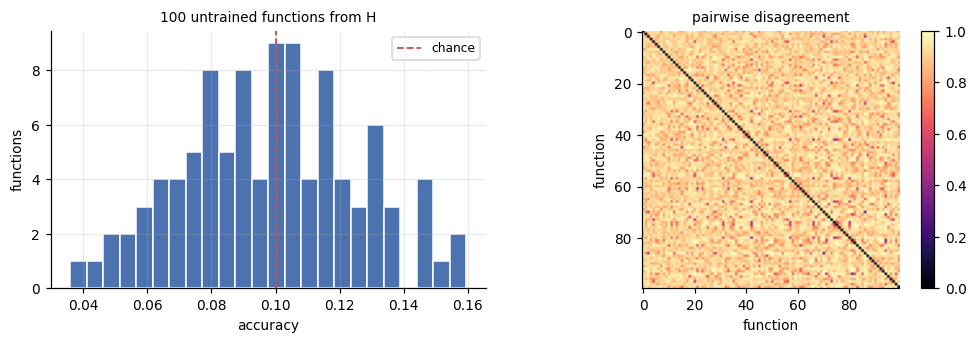

In [22]:
# [complete] How different are these functions from each other? Pairwise disagreement is the
# natural metric on behaviour: the fraction of probe examples where two functions predict
# differently. 0 = behaviourally identical, and ~0.9 would be near-independent random labellers.
def disagreement_matrix(behaviour: np.ndarray) -> np.ndarray:
    n = len(behaviour)
    D = np.zeros((n, n), dtype=DTYPE)
    for i in range(n):
        D[i] = (behaviour != behaviour[i]).mean(axis=1)
    return D

D = disagreement_matrix(behaviour)
iu = np.triu_indices(len(D), k=1)
print("pairwise disagreement: mean %.4f  min %.4f  max %.4f"
      % (D[iu].mean(), D[iu].min(), D[iu].max()))

# How many distinct classes does each untrained function actually use? Random nets are usually
# heavily biased towards a couple of classes -- a fact worth explaining rather than glossing over.
classes_used = np.array([len(np.unique(b)) for b in behaviour])
print("distinct classes predicted per function: mean %.2f of 10 (min %d, max %d)"
      % (classes_used.mean(), classes_used.min(), classes_used.max()))

# The closest and furthest pair, answering 7.5's "who is closer to whom".
d = D.copy(); np.fill_diagonal(d, np.inf)
i, j = np.unravel_index(np.argmin(d), d.shape)
np.fill_diagonal(d, -np.inf)
k, l = np.unravel_index(np.argmax(d), d.shape)
print("most similar pair : f%d, f%d  (disagree on %.1f%% of probes)" % (i, j, 100 * D[i, j]))
print("most different    : f%d, f%d  (disagree on %.1f%% of probes)" % (k, l, 100 * D[k, l]))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(family_acc, bins=24, color="#4C72B0", edgecolor="white")
axes[0].axvline(1 / N_CLASSES, color="#C44E52", ls="--", lw=1.2, label="chance")
axes[0].set_xlabel("accuracy"); axes[0].set_ylabel("functions")
axes[0].set_title("100 untrained functions from H", fontsize=9); axes[0].legend(fontsize=8)

im = axes[1].imshow(D, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("pairwise disagreement", fontsize=9)
axes[1].set_xlabel("function"); axes[1].set_ylabel("function"); axes[1].grid(False)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

### 5.2 Reading the behaviour matrix

`behaviour` is a 100 × 2000 matrix of predicted classes; `D[i,j]` is the fraction of probes on
which functions *i* and *j* disagree. See the report for the analysis.

### 5.3 Expanding and reducing the family

Scaling the initialisation variance changes how spread out the family's behaviour is, without
touching the architecture -- isolating diversity as its own variable, separate from depth or width.


scale    disagreement   mean acc     std acc     classes used  mean conf
0.05     0.9052         0.0883       0.0260      9.23          0.1002
0.25     0.9052         0.0883       0.0260      9.23          0.1044
1.00     0.9052         0.0883       0.0260      9.23          0.1856
4.00     0.9052         0.0883       0.0260      9.23          0.8399
16.00    0.9052         0.0883       0.0260      9.23          0.9898


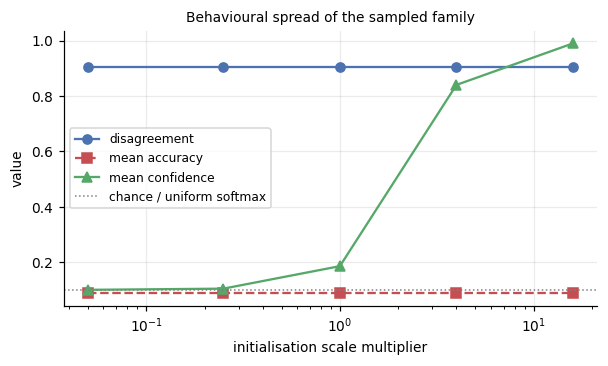


disagreement/accuracy/classes-used are flat by construction (argmax is scale-invariant
for a zero-bias ReLU net). Confidence is not argmax-derived, and rises with scale -- see
the report for the full argument and what it implies about the He/Xavier default in 3.2.


In [23]:
# [complete] Behavioural diversity as a function of initialisation scale.
scales = [0.05, 0.25, 1.0, 4.0, 16.0]
rows = []
for s in scales:
    beh_s, acc_s, conf_s = sample_family(n_functions=30, scale=s, seed=5)
    Ds = disagreement_matrix(beh_s)
    ius = np.triu_indices(len(Ds), k=1)
    rows.append((s, Ds[ius].mean(), acc_s.mean(), acc_s.std(),
                 float(np.mean([len(np.unique(b)) for b in beh_s])), conf_s.mean()))

print("%-8s %-14s %-12s %-11s %-14s%s" %
      ("scale", "disagreement", "mean acc", "std acc", "classes used", "mean conf"))
for s, dis, ma, sa, cu, mc in rows:
    print("%-8.2f %-14.4f %-12.4f %-11.4f %-14.2f%.4f" % (s, dis, ma, sa, cu, mc))

# disagreement, accuracy and classes-used are all functions of argmax(logits) alone, and ReLU
# with zero biases is positively homogeneous: scaling every weight by c>0 scales the logits by
# c too, and argmax(c*z) = argmax(z) for any c>0. So those three columns are mathematically
# guaranteed to be flat across this sweep -- confirmed above -- regardless of how the actual
# function is changing. Mean max-softmax confidence is not argmax-derived, so it is the one
# column here that actually shows what varying the scale does.
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.semilogx([r[0] for r in rows], [r[1] for r in rows], "o-", color="#4C72B0", label="disagreement")
ax.semilogx([r[0] for r in rows], [r[2] for r in rows], "s--", color="#C44E52", label="mean accuracy")
ax.semilogx([r[0] for r in rows], [r[5] for r in rows], "^-", color="#55A868", label="mean confidence")
ax.axhline(1 / N_CLASSES, color="grey", ls=":", lw=1, label="chance / uniform softmax")
ax.set_xlabel("initialisation scale multiplier"); ax.set_ylabel("value")
ax.set_title("Behavioural spread of the sampled family", fontsize=9)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print()
print("disagreement/accuracy/classes-used are flat by construction (argmax is scale-invariant")
print("for a zero-bias ReLU net). Confidence is not argmax-derived, and rises with scale -- see")
print("the report for the full argument and what it implies about the He/Xavier default in 3.2.")

### 5.4 Naive update in this family

Runs §4.1's random local search on one sampled function, for comparison against §6's gradient
training. See the report for the analysis.

before: loss 2.3509  accuracy 0.1290


naive update: accepted 91 of 852 candidates (10.7%)
after : loss 1.2774  accuracy 0.5770  (1.0s, 1200 forward passes)


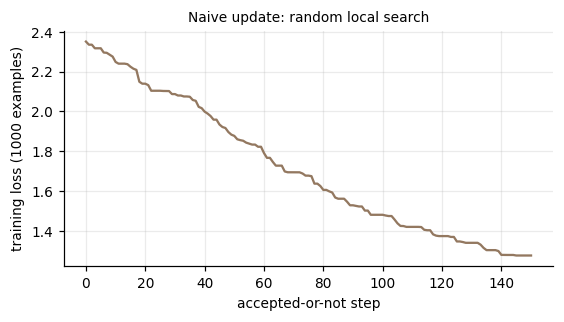

In [24]:
# [complete] Requires TODOs #1, #2, #4, #5 (no optimizer needed -- this one uses no gradients).
_naive_model = MLP(FAMILY_SIZES, make_rng(3))
_naive_crit = SoftmaxCrossEntropy()
_Xn, _yn = X_train[:1000], y_train[:1000]

print("before: loss %.4f  accuracy %.4f"
      % (_naive_crit.forward(_naive_model.forward(_Xn, training=False), _yn),
         (_naive_model.predict(_Xn) == _yn).mean()))

t0 = time.time()
naive_hist = naive_update_train(_naive_model, _naive_crit, _Xn, _yn,
                                steps=150, n_candidates=8, sigma=0.02, rng=make_rng(11))
elapsed_naive = time.time() - t0

print("after : loss %.4f  accuracy %.4f  (%.1fs, %d forward passes)"
      % (naive_hist[-1], (_naive_model.predict(_Xn) == _yn).mean(),
         elapsed_naive, 150 * 8))

fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(naive_hist, color="#937860")
ax.set_xlabel("accepted-or-not step"); ax.set_ylabel("training loss (1000 examples)")
ax.set_title("Naive update: random local search", fontsize=9)
plt.tight_layout(); plt.show()

---
## 6. Training

Mini-batch gradient descent; the four lines that matter:

```
logits = model.forward(X_batch)        # 1. predict
loss   = criterion.forward(logits, y)  # 2. score
model.backward(criterion.backward())   # 3. attribute blame
opt.step(model.gradients())            # 4. adjust
```

Shuffled every epoch, batch 128, early stopping on **validation loss** (not accuracy — loss
moves before a discrete argmax flips, so it detects overfitting sooner). Reported training loss
includes the $L^2$ penalty; validation loss does not.

In [25]:
# [complete] Mini-batch iteration.
def iterate_minibatches(X: np.ndarray, y: np.ndarray, batch_size: int,
                        rng: np.random.Generator, shuffle: bool = True):
    """Yield (X_batch, y_batch). The last batch may be smaller; the 1/N in the loss handles that."""
    idx = rng.permutation(len(X)) if shuffle else np.arange(len(X))
    for start in range(0, len(X), batch_size):
        sl = idx[start:start + batch_size]
        yield X[sl], y[sl]


def evaluate(model: MLP, criterion: SoftmaxCrossEntropy, X: np.ndarray, y: np.ndarray,
             batch_size: int = 2048) -> Tuple[float, float]:
    """(mean cross-entropy, accuracy) in inference mode. Batched to bound peak memory."""
    total_loss, correct = 0.0, 0
    for s in range(0, len(X), batch_size):
        xb, yb = X[s:s + batch_size], y[s:s + batch_size]
        logits = model.forward(xb, training=False)
        total_loss += criterion.forward(logits, yb) * len(xb)   # un-average, then re-average
        correct += int((logits.argmax(axis=1) == yb).sum())
    return total_loss / len(X), correct / len(X)

In [26]:
# [complete] The training loop.
@dataclass
class History:
    """Per-epoch record. Everything 7 plots comes from here."""
    train_loss: List[float] = field(default_factory=list)
    train_acc: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    val_acc: List[float] = field(default_factory=list)
    epoch_time: List[float] = field(default_factory=list)
    best_epoch: int = -1
    best_val_loss: float = float("inf")
    stopped_early: bool = False


def train(model: MLP,
          X_tr: np.ndarray, y_tr: np.ndarray,
          X_va: np.ndarray, y_va: np.ndarray,
          optimizer: str = "adam",
          lr: float = 1e-3,
          epochs: int = 20,
          batch_size: int = 128,
          patience: int = 5,
          restore_best: bool = True,
          lr_decay: float = 1.0,
          seed: int = SEED,
          verbose: bool = True,
          **opt_kwargs) -> History:
    """Mini-batch training with early stopping on validation loss.

    patience   : epochs without validation-loss improvement before stopping (None disables it)
    lr_decay   : multiplied into the learning rate each epoch (1.0 = constant)
    """
    criterion = SoftmaxCrossEntropy()
    opt = OPTIMIZERS[optimizer](model.parameters(), lr=lr, **opt_kwargs)
    rng_train = make_rng(seed)
    hist = History()
    best_params: Optional[List[np.ndarray]] = None
    since_improved = 0

    if verbose:
        print(model, "|", opt, "| batch", batch_size)
        print("%-6s %-12s %-11s %-12s %-11s %s" %
              ("epoch", "train loss", "train acc", "val loss", "val acc", "sec"))

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        opt.lr = lr * (lr_decay ** (epoch - 1))

        running, n_seen = 0.0, 0
        for xb, yb in iterate_minibatches(X_tr, y_tr, batch_size, rng_train):
            logits = model.forward(xb, training=True)          # 1. predict
            loss = criterion.forward(logits, yb)               # 2. score
            model.backward(criterion.backward())               # 3. attribute blame
            opt.step(model.gradients())                        # 4. adjust
            running += loss * len(xb)
            n_seen += len(xb)

        # Training loss reported with the L2 penalty (it is part of the objective being minimised);
        # accuracy measured in inference mode so dropout does not distort it.
        train_loss = running / n_seen + model.l2_penalty()
        _, train_acc = evaluate(model, criterion, X_tr[:10_000], y_tr[:10_000])
        val_loss, val_acc = evaluate(model, criterion, X_va, y_va)

        hist.train_loss.append(train_loss); hist.train_acc.append(train_acc)
        hist.val_loss.append(val_loss);     hist.val_acc.append(val_acc)
        hist.epoch_time.append(time.time() - t0)

        if val_loss < hist.best_val_loss - 1e-6:
            hist.best_val_loss, hist.best_epoch, since_improved = val_loss, epoch, 0
            if restore_best:
                best_params = [p.copy() for p in model.parameters()]
        else:
            since_improved += 1

        if verbose:
            flag = "  <- best" if hist.best_epoch == epoch else ""
            print("%-6d %-12.4f %-11.4f %-12.4f %-11.4f %.1f%s" %
                  (epoch, train_loss, train_acc, val_loss, val_acc, hist.epoch_time[-1], flag))

        if patience is not None and since_improved >= patience:
            hist.stopped_early = True
            if verbose:
                print("early stop: %d epochs without improvement" % patience)
            break

    if restore_best and best_params is not None:
        for p, best in zip(model.parameters(), best_params):
            p[...] = best                       # in place, per the note in 4.2
        if verbose:
            print("restored epoch %d (val loss %.4f)" % (hist.best_epoch, hist.best_val_loss))
    return hist

### 6.2 Train the reference model

The architecture and hyperparameters below are a **starting point, not a result**. Criterion B is
explicit that listing "3 layers, 128 units, Adam" without justification caps the mark at *Pass*, so
§7.4's ablations exist to turn each of these into a defended choice. Run them, then come back and
edit this cell to your own configuration and record why.

In [27]:
# [complete] Requires every TODO except #3 (dropout). ~1-3 s per epoch on a Colab CPU.
CONFIG = dict(
    layer_sizes=[N_FEATURES, 256, 128, N_CLASSES],
    activation="relu",
    init="he",
    l2=0.0,
    dropout=0.0,
    optimizer="adam",
    lr=1e-3,
    epochs=30,
    batch_size=128,
    patience=5,
)

model = MLP(CONFIG["layer_sizes"], make_rng(SEED),
            activation=CONFIG["activation"], init=CONFIG["init"],
            l2=CONFIG["l2"], dropout=CONFIG["dropout"])

t0 = time.time()
history = train(model, X_train, y_train, X_val, y_val,
                optimizer=CONFIG["optimizer"], lr=CONFIG["lr"],
                epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
                patience=CONFIG["patience"], seed=SEED)
print("\ntotal training time %.1fs" % (time.time() - t0))

model.save("mlp_reference.npz")
print("weights written to mlp_reference.npz")

MLP(784 -> 256 -> 128 -> 10, 235146 params) | Adam(lr=0.001) | batch 128
epoch  train loss   train acc   val loss     val acc     sec


1      0.2833       0.9638      0.1415       0.9561      2.5  <- best


2      0.1077       0.9793      0.1068       0.9665      2.6  <- best


3      0.0706       0.9855      0.0889       0.9722      2.5  <- best


4      0.0493       0.9905      0.0841       0.9754      2.5  <- best


...

6      0.0280       0.9928      0.0950       0.9738      2.5


7      0.0223       0.9959      0.0880       0.9764      2.5


8      0.0163       0.9968      0.0823       0.9774      2.5


9      0.0116       0.9969      0.0834       0.9794      2.5


10     0.0108       0.9971      0.0958       0.9780      2.5
early stop: 5 epochs without improvement
restored epoch 5 (val loss 0.0819)

total training time 25.1s
weights written to mlp_reference.npz


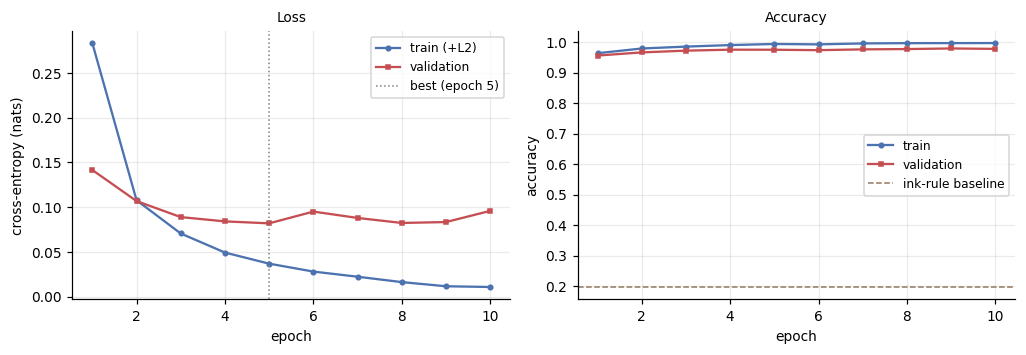

best epoch 5 | val loss 0.0819 | val acc 0.9752 | stopped early: True


In [28]:
# [complete] Learning curves. The gap between the two lines is the generalisation gap; the epoch
# where validation loss turns up is where the model starts fitting noise.
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3))
ep = np.arange(1, len(history.train_loss) + 1)

axes[0].plot(ep, history.train_loss, "o-", ms=3, color="#4C72B0", label="train (+L2)")
axes[0].plot(ep, history.val_loss, "s-", ms=3, color="#C44E52", label="validation")
if history.best_epoch > 0:
    axes[0].axvline(history.best_epoch, color="grey", ls=":", lw=1,
                    label="best (epoch %d)" % history.best_epoch)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy (nats)")
axes[0].set_title("Loss", fontsize=9); axes[0].legend(fontsize=8)

axes[1].plot(ep, history.train_acc, "o-", ms=3, color="#4C72B0", label="train")
axes[1].plot(ep, history.val_acc, "s-", ms=3, color="#C44E52", label="validation")
axes[1].axhline(acc_ink, color="#937860", ls="--", lw=1, label="ink-rule baseline")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy", fontsize=9); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print("best epoch %d | val loss %.4f | val acc %.4f | stopped early: %s"
      % (history.best_epoch, history.best_val_loss,
         history.val_acc[history.best_epoch - 1], history.stopped_early))

---
## 7. Evaluation (Criterion C)

The rubric here escalates in a specific way. Reporting accuracy on a held-out set is *Pass*. Getting
to *Fair* needs task-relevant metrics, per-class behaviour, and proper statistical reporting. *
Excellent* needs the gap between the loss and the actual objective identified with concrete cases
and a mitigation. Full marks want a metric or analysis that captures the task's value better than
the standard ones do.

The sections below are built to support each rung: §7.1–7.2 per-class metrics and error analysis,
§7.3 variance across seeds, §7.4 ablations, §7.5 the loss-versus-objective analysis with a reject
option. The numbers are produced for you; **the readings are yours to write** — and the readings are
what is graded.

All metrics are implemented from scratch, since Option 1 rules out importing them.

In [29]:
# [complete] Metrics, from the definitions.
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                     n_classes: int = N_CLASSES) -> np.ndarray:
    """cm[i, j] = number of examples with true class i predicted as j. Rows sum to class support."""
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm

def per_class_metrics(cm: np.ndarray) -> Dict[str, np.ndarray]:
    """Precision, recall, F1 and support per class, straight from the confusion matrix.

    precision_c = TP_c / (TP_c + FP_c)  -- of what was predicted c, how much was c
    recall_c    = TP_c / (TP_c + FN_c)  -- of what truly was c, how much was found
    F1_c        = harmonic mean of the two (harmonic, so one bad half cannot be hidden by the other)
    """
    tp = np.diag(cm).astype(DTYPE)
    predicted = cm.sum(axis=0).astype(DTYPE)     # column sums: everything called c
    actual = cm.sum(axis=1).astype(DTYPE)        # row sums: everything that is c
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.where(predicted > 0, tp / predicted, 0.0)
        recall = np.where(actual > 0, tp / actual, 0.0)
        f1 = np.where(precision + recall > 0, 2 * precision * recall / (precision + recall), 0.0)
    return {"precision": precision, "recall": recall, "f1": f1, "support": actual}

def classification_report(y_true: np.ndarray, y_pred: np.ndarray,
                          n_classes: int = N_CLASSES, title: str = "") -> Dict[str, float]:
    cm = confusion_matrix(y_true, y_pred, n_classes)
    m = per_class_metrics(cm)
    accuracy = float(np.trace(cm) / cm.sum())
    support = m["support"]
    macro_f1 = float(m["f1"].mean())                            # unweighted: every class counts once
    weighted_f1 = float((m["f1"] * support).sum() / support.sum())

    if title:
        print(title)
    print("%-7s %-11s %-9s %-9s %s" % ("class", "precision", "recall", "f1", "support"))
    for c in range(n_classes):
        print("%-7d %-11.4f %-9.4f %-9.4f %d"
              % (c, m["precision"][c], m["recall"][c], m["f1"][c], support[c]))
    print("-" * 48)
    print("accuracy     %.4f   (%d of %d)" % (accuracy, np.trace(cm), cm.sum()))
    print("macro F1     %.4f" % macro_f1)
    print("weighted F1  %.4f" % weighted_f1)
    return {"accuracy": accuracy, "macro_f1": macro_f1, "weighted_f1": weighted_f1}

### 7.1 The headline numbers

MNIST's classes are near-balanced (the rarest, class 5, is 8.9% of the test set against 11.4% for
class 1), so accuracy is not misleading here in the way it would be on an imbalanced task — but
macro F1 is reported alongside it anyway, because it weights every class equally and so exposes a
single weak class that accuracy would average away. Saying *why* accuracy is defensible for this
task is worth more than reporting a longer list of metrics.

This is the one place the test set is used.

In [30]:
# [complete] Final evaluation. Validation is what selected the model; test is reported once.
criterion = SoftmaxCrossEntropy()

val_loss, val_acc = evaluate(model, criterion, X_val, y_val)
test_loss, test_acc = evaluate(model, criterion, X_test, y_test)

print("validation : loss %.4f  accuracy %.4f" % (val_loss, val_acc))
print("test       : loss %.4f  accuracy %.4f" % (test_loss, test_acc))
print("generalisation gap (train acc - test acc): %.4f"
      % (history.train_acc[history.best_epoch - 1] - test_acc))
print()

probs_test = model.predict_proba(X_test)
preds_test = probs_test.argmax(axis=1)
test_report = classification_report(y_test, preds_test, title="Per-class test performance")

print()
print("for context -- baselines from 2.3:")
print("  chance %.4f | majority class %.4f | ink rules %.4f" % (1 / N_CLASSES, acc_const, acc_ink))

validation : loss 0.0819  accuracy 0.9752


test       : loss 0.0718  accuracy 0.9779
generalisation gap (train acc - test acc): 0.0162

Per-class test performance
class   precision   recall    f1        support
0       0.9710      0.9918    0.9813    980
1       0.9809      0.9930    0.9869    1135
2       0.9833      0.9719    0.9776    1032
3       0.9715      0.9782    0.9748    1010
4       0.9815      0.9735    0.9775    982
5       0.9897      0.9697    0.9796    892
6       0.9781      0.9812    0.9797    958
7       0.9731      0.9844    0.9787    1028
8       0.9904      0.9528    0.9712    974
9       0.9620      0.9792    0.9705    1009
------------------------------------------------
accuracy     0.9779   (9779 of 10000)
macro F1     0.9778
weighted F1  0.9779

for context -- baselines from 2.3:
  chance 0.1000 | majority class 0.1205 | ink rules 0.1970


### 7.2 Where the errors are

The confusion matrix is the difference between "96% accurate" and knowing what the model actually
does. The rubric's *Fair* band asks for exactly this class-specific analysis.

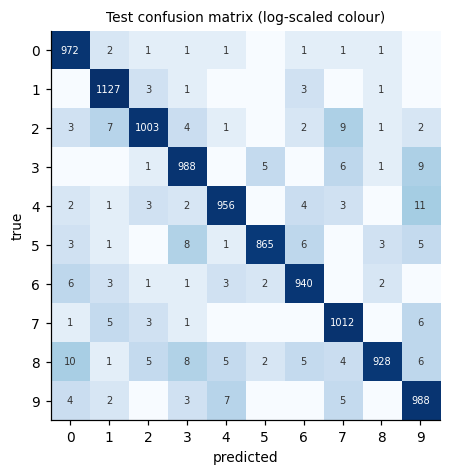

Most frequent confusions (true -> predicted):
  4 -> 9 :  11   (5.0% of all 221 errors)
  8 -> 0 :  10   (4.5% of all 221 errors)
  3 -> 9 :   9   (4.1% of all 221 errors)
  2 -> 7 :   9   (4.1% of all 221 errors)
  8 -> 3 :   8   (3.6% of all 221 errors)
  5 -> 3 :   8   (3.6% of all 221 errors)
  9 -> 4 :   7   (3.2% of all 221 errors)
  2 -> 1 :   7   (3.2% of all 221 errors)
  8 -> 9 :   6   (2.7% of all 221 errors)
  7 -> 9 :   6   (2.7% of all 221 errors)


In [31]:
# [complete] Confusion matrix, off-diagonal ranking, and the errors themselves.
cm_test = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(5.0, 4.4))
# Log scale: the diagonal is ~100x the off-diagonal, and on a linear scale the errors -- the whole
# point of the plot -- would be invisible.
im = ax.imshow(np.log1p(cm_test), cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Test confusion matrix (log-scaled colour)", fontsize=9)
ax.grid(False)
for i in range(10):
    for j in range(10):
        n = cm_test[i, j]
        if n:
            ax.text(j, i, str(n), ha="center", va="center", fontsize=6.5,
                    color="white" if i == j else "#333333")
plt.tight_layout(); plt.show()

off = cm_test.copy(); np.fill_diagonal(off, 0)
pairs = [(off[i, j], i, j) for i in range(10) for j in range(10) if off[i, j]]
pairs.sort(reverse=True)
print("Most frequent confusions (true -> predicted):")
for n, i, j in pairs[:10]:
    print("  %d -> %d : %3d   (%.1f%% of all %d errors)"
          % (i, j, n, 100 * n / off.sum(), int(off.sum())))

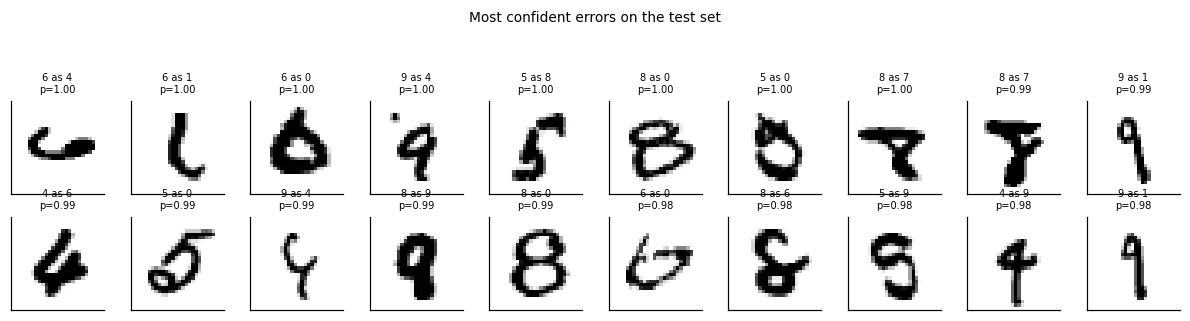

total errors: 221 of 10000 (2.21%)


In [32]:
# [complete] A gallery of actual mistakes, most confident first -- these are the informative ones.
wrong = np.flatnonzero(preds_test != y_test)
conf_wrong = probs_test[wrong, preds_test[wrong]]
order = wrong[np.argsort(-conf_wrong)]

n_show = min(20, len(order))
fig, axes = plt.subplots(2, 10, figsize=(11, 2.6))
for k in range(20):
    ax = axes[k // 10, k % 10]
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if k < n_show:
        i = order[k]
        ax.imshow(raw_test_images[i], cmap="gray_r")
        ax.set_title("%d as %d\np=%.2f" % (y_test[i], preds_test[i], probs_test[i, preds_test[i]]),
                     fontsize=6.5)
    else:
        ax.axis("off")
fig.suptitle("Most confident errors on the test set", y=1.10, fontsize=9)
plt.tight_layout(); plt.show()

print("total errors: %d of %d (%.2f%%)" % (len(wrong), len(y_test), 100 * len(wrong) / len(y_test)))

### 7.3 Is the result stable?

A single accuracy figure from a single seed is one sample from a distribution: initialisation,
shuffling and the split all vary. The rubric's *Fair* band asks for mean/std or cross-validation, so
the pipeline is repeated across seeds and reported as mean ± std.

Variance is measured on **validation**, not test — the test set is for the one final number in §7.1.
Fewer epochs here keep it affordable; the point is the spread, not the peak.

In [33]:
# [complete] Repeated runs. ~3 x 15 epochs; a couple of minutes on a Colab CPU.
N_SEEDS = 3
seed_results = []

for s in range(N_SEEDS):
    seed = SEED + 1000 * (s + 1)
    m_s = MLP(CONFIG["layer_sizes"], make_rng(seed),
              activation=CONFIG["activation"], init=CONFIG["init"], l2=CONFIG["l2"])
    h_s = train(m_s, X_train, y_train, X_val, y_val,
                optimizer=CONFIG["optimizer"], lr=CONFIG["lr"],
                epochs=15, batch_size=CONFIG["batch_size"], patience=4,
                seed=seed, verbose=False)
    best = h_s.val_acc[h_s.best_epoch - 1]
    seed_results.append(best)
    print("seed %d: best val acc %.4f (epoch %d)" % (seed, best, h_s.best_epoch))

arr = np.array(seed_results)
if len(arr) > 1:
    # ddof=1: these seeds are a sample from the distribution of runs, not the whole population.
    print("\nval accuracy over %d seeds: %.4f +/- %.4f  (min %.4f, max %.4f)"
          % (N_SEEDS, arr.mean(), arr.std(ddof=1), arr.min(), arr.max()))
else:
    print("\nval accuracy: %.4f from a single seed -- no spread to report. Set N_SEEDS >= 3 "
          "before quoting a +/- anywhere." % arr.mean())

seed 20251909: best val acc 0.9765 (epoch 6)


seed 20252909: best val acc 0.9749 (epoch 7)


seed 20253909: best val acc 0.9723 (epoch 4)

val accuracy over 3 seeds: 0.9746 +/- 0.0021  (min 0.9723, max 0.9765)


### 7.4 Ablations: turning defaults into decisions

Criterion B caps at *Pass* if the architecture and optimizer are stated but not justified — "why 256
units, why Adam, why this learning rate" needs an answer grounded in something. These runs are that
grounding.

Each varies one factor from `CONFIG` at reduced epochs. Read every difference against the noise
threshold from §7.3 before calling it real.

In [34]:
# [complete] One-factor-at-a-time ablation harness. ~15-20 runs x ~15 s; budget a few minutes.
def run_config(overrides: Dict, epochs: int = 12, patience: int = 4,
               seed: int = SEED, verbose: bool = False) -> Dict[str, float]:
    """Train one configuration and return its best validation performance."""
    cfg = dict(CONFIG); cfg.update(overrides)
    m = MLP(cfg["layer_sizes"], make_rng(seed), activation=cfg["activation"],
            init=cfg["init"], l2=cfg["l2"], dropout=cfg["dropout"])
    t0 = time.time()
    h = train(m, X_train, y_train, X_val, y_val,
              optimizer=cfg["optimizer"], lr=cfg["lr"], epochs=epochs,
              batch_size=cfg["batch_size"], patience=patience, seed=seed, verbose=verbose)
    i = h.best_epoch - 1
    return {"val_acc": h.val_acc[i], "val_loss": h.val_loss[i],
            "train_acc": h.train_acc[i], "gap": h.train_acc[i] - h.val_acc[i],
            "best_epoch": h.best_epoch, "params": m.n_params, "seconds": time.time() - t0}

ABLATIONS: List[Tuple[str, Dict]] = [
    # depth and width: does capacity help, and where does it stop helping?
    ("depth 0 hidden (linear)",    {"layer_sizes": [N_FEATURES, N_CLASSES]}),
    ("depth 1 x 128",              {"layer_sizes": [N_FEATURES, 128, N_CLASSES]}),
    ("depth 2 x [256,128] (ref)",  {}),
    ("depth 3 x [256,128,64]",     {"layer_sizes": [N_FEATURES, 256, 128, 64, N_CLASSES]}),
    ("width 2 x [64,32]",          {"layer_sizes": [N_FEATURES, 64, 32, N_CLASSES]}),
    ("width 2 x [512,256]",        {"layer_sizes": [N_FEATURES, 512, 256, N_CLASSES]}),
    # optimizer: the 4.1-4.4 progression, measured
    ("optimizer sgd lr=0.1",       {"optimizer": "sgd", "lr": 0.1}),
    ("optimizer momentum lr=0.05", {"optimizer": "momentum", "lr": 0.05}),
    ("optimizer adam lr=1e-3",     {}),
    # learning rate sensitivity
    ("adam lr=1e-4",               {"lr": 1e-4}),
    ("adam lr=1e-2",               {"lr": 1e-2}),
    # activation and initialisation
    ("activation tanh",            {"activation": "tanh"}),
    ("init xavier",                {"init": "xavier"}),
    # regularisation -- the dropout rows need TODO #3
    ("l2 1e-4",                    {"l2": 1e-4}),
    ("l2 1e-3",                    {"l2": 1e-3}),
    ("dropout 0.2",                {"dropout": 0.2}),
    ("batch 512",                  {"batch_size": 512}),
]

results = {}
print("%-30s %-10s %-11s %-9s %-9s %s" % ("config", "val acc", "val loss", "gap", "params", "sec"))
for name, ov in ABLATIONS:
    try:
        r = run_config(ov)
        results[name] = r
        print("%-30s %-10.4f %-11.4f %-9.4f %-9d %.0f"
              % (name, r["val_acc"], r["val_loss"], r["gap"], r["params"], r["seconds"]))
    except NotImplementedError as e:
        print("%-30s skipped (%s)" % (name, e))

config                         val acc    val loss    gap       params    sec


depth 0 hidden (linear)        0.9228     0.2825      0.0033    7850      2


depth 1 x 128                  0.9738     0.0902      0.0216    101770    8


depth 2 x [256,128] (ref)      0.9752     0.0819      0.0189    235146    23


depth 3 x [256,128,64]         0.9743     0.0929      0.0186    242762    23


...

init xavier                    0.9760     0.0815      0.0193    235146    51


l2 1e-4                        0.9784     0.0780      0.0168    235146    59


l2 1e-3                        0.9757     0.0827      0.0121    235146    60


dropout 0.2                    0.9786     0.0726      0.0154    235146    57


batch 512                      0.9751     0.0819      0.0188    235146    28


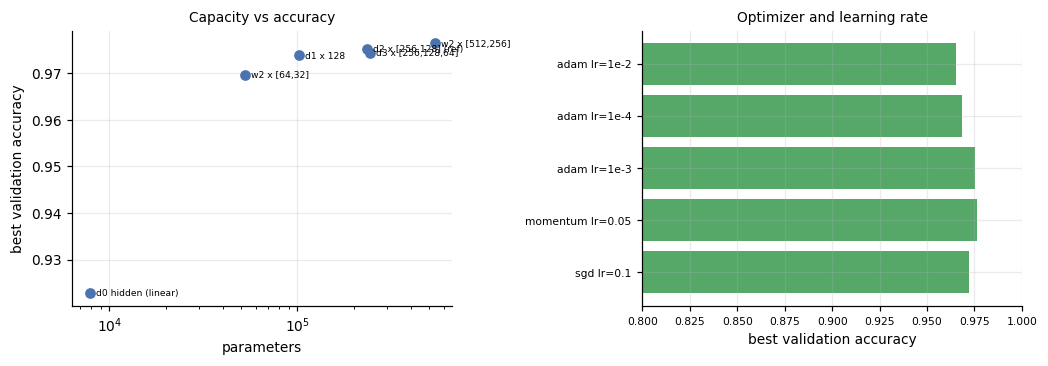

In [35]:
# [complete] Two views of the ablation table: capacity against accuracy, and the optimizer race.
if results:
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))

    cap = [(n, r) for n, r in results.items() if n.startswith(("depth", "width"))]
    if cap:
        xs = [r["params"] for _, r in cap]
        ys = [r["val_acc"] for _, r in cap]
        axes[0].semilogx(xs, ys, "o", color="#4C72B0")
        for (n, r) in cap:
            axes[0].annotate(n.replace("depth ", "d").replace("width ", "w"),
                             (r["params"], r["val_acc"]), fontsize=6,
                             textcoords="offset points", xytext=(4, -2))
        axes[0].set_xlabel("parameters"); axes[0].set_ylabel("best validation accuracy")
        axes[0].set_title("Capacity vs accuracy", fontsize=9)

    opt = [(n, r) for n, r in results.items() if n.startswith(("optimizer", "adam lr"))]
    if opt:
        axes[1].barh([n.replace("optimizer ", "") for n, _ in opt],
                     [r["val_acc"] for _, r in opt], color="#55A868")
        axes[1].set_xlim(0.8, 1.0)
        axes[1].set_xlabel("best validation accuracy")
        axes[1].set_title("Optimizer and learning rate", fontsize=9)
        axes[1].tick_params(labelsize=7)

    plt.tight_layout(); plt.show()

### 7.5 Loss function versus task objective

Cross-entropy is a surrogate for accuracy (which has zero gradient almost everywhere). §7.5a–c
measure where the two diverge: model selection, calibration, and a cost-derived reject option.
See the report for the analysis.

In [36]:
# [complete] 7.5a -- do loss and accuracy pick the same epoch?
best_loss_epoch = int(np.argmin(history.val_loss)) + 1
best_acc_epoch = int(np.argmax(history.val_acc)) + 1

print("epoch chosen by minimum validation loss     : %d (acc there %.4f)"
      % (best_loss_epoch, history.val_acc[best_loss_epoch - 1]))
print("epoch chosen by maximum validation accuracy : %d (acc there %.4f)"
      % (best_acc_epoch, history.val_acc[best_acc_epoch - 1]))

if best_loss_epoch != best_acc_epoch:
    delta = history.val_acc[best_acc_epoch - 1] - history.val_acc[best_loss_epoch - 1]
    print("\nThe two criteria disagree: early stopping on loss costs %.4f accuracy (%.0f test digits"
          " at this scale)." % (delta, delta * len(y_test)))
    print("That is a measured instance of the surrogate diverging from the objective -- not a")
    print("hypothetical.")
else:
    print("\nThey agree in this run.")

# A minimal two-example demonstration that the ordering can genuinely reverse.
print("\nA constructed case (two examples, true classes 0 and 1):")
logits_a = np.array([[2.0, 1.0], [1.0, 2.0]])      # both correct, moderate confidence
logits_b = np.array([[6.0, 0.0], [0.0, -1.0]])     # one very confident hit, one confident miss
y_demo = np.array([0, 1])
for tag, lg in (("model A", logits_a), ("model B", logits_b)):
    p = softmax(lg)
    ce = -np.mean(np.log(p[np.arange(2), y_demo]))
    acc = (lg.argmax(1) == y_demo).mean()
    print("  %s: cross-entropy %.4f   accuracy %.2f" % (tag, ce, acc))
print("  Loss prefers whichever number is lower; the task prefers whichever accuracy is higher.")

epoch chosen by minimum validation loss     : 5 (acc there 0.9752)
epoch chosen by maximum validation accuracy : 9 (acc there 0.9794)

The two criteria disagree: early stopping on loss costs 0.0042 accuracy (42 test digits at this scale).
That is a measured instance of the surrogate diverging from the objective -- not a
hypothetical.

A constructed case (two examples, true classes 0 and 1):
  model A: cross-entropy 0.3133   accuracy 1.00
  model B: cross-entropy 0.6579   accuracy 0.50
  Loss prefers whichever number is lower; the task prefers whichever accuracy is higher.


mean confidence  0.9822
actual accuracy  0.9779
overconfidence   +0.0043  (mean confidence - accuracy)
ECE (15 bins)    0.0050


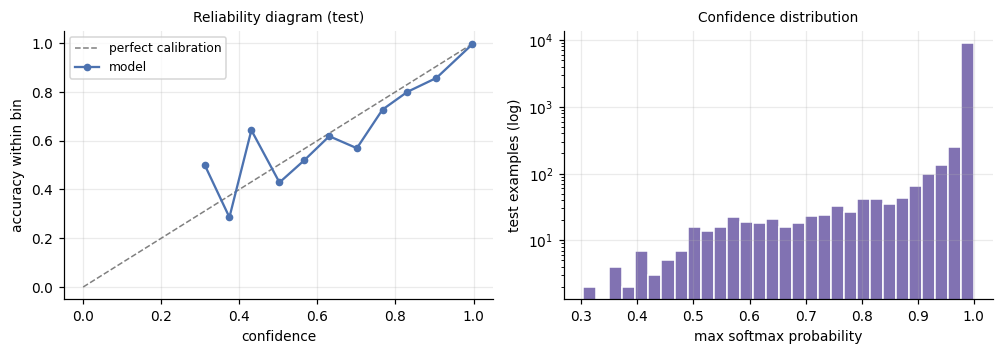

In [37]:
# [complete] 7.5b -- calibration. ECE bins predictions by confidence and asks whether, within a
# bin, the model is right as often as it claims to be.
def expected_calibration_error(probs: np.ndarray, y: np.ndarray,
                               n_bins: int = 15) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    """Returns (ECE, bin_confidence, bin_accuracy, bin_count).

    ECE = sum_b (n_b / N) * | accuracy(b) - confidence(b) |, a support-weighted average of the gap
    between claimed and achieved correctness. Perfect calibration is 0.
    """
    conf = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == y).astype(DTYPE)
    edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_conf = np.zeros(n_bins); bin_acc = np.zeros(n_bins); bin_n = np.zeros(n_bins, dtype=np.int64)
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        mask = (conf > lo) & (conf <= hi) if b > 0 else (conf >= lo) & (conf <= hi)
        bin_n[b] = int(mask.sum())
        if bin_n[b]:
            bin_conf[b] = conf[mask].mean()
            bin_acc[b] = correct[mask].mean()

    ece = float(np.sum(bin_n / len(y) * np.abs(bin_acc - bin_conf)))
    return ece, bin_conf, bin_acc, bin_n

ece, bin_conf, bin_acc, bin_n = expected_calibration_error(probs_test, y_test)
mean_conf = probs_test.max(axis=1).mean()

print("mean confidence  %.4f" % mean_conf)
print("actual accuracy  %.4f" % test_acc)
print("overconfidence   %+.4f  (mean confidence - accuracy)" % (mean_conf - test_acc))
print("ECE (15 bins)    %.4f" % ece)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))
nz = bin_n > 0
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1, label="perfect calibration")
axes[0].plot(bin_conf[nz], bin_acc[nz], "o-", color="#4C72B0", ms=4, label="model")
axes[0].set_xlabel("confidence"); axes[0].set_ylabel("accuracy within bin")
axes[0].set_title("Reliability diagram (test)", fontsize=9); axes[0].legend(fontsize=8)

axes[1].hist(probs_test.max(axis=1), bins=30, color="#8172B2", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("max softmax probability"); axes[1].set_ylabel("test examples (log)")
axes[1].set_title("Confidence distribution", fontsize=9)
plt.tight_layout(); plt.show()

threshold   coverage    acc accepted   errors served   abstentions
0.000       1.0000      0.9779         221             0
0.500       0.9960      0.9800         199             40
0.900       0.9502      0.9935         62              498
0.950       0.9281      0.9961         36              719
0.990       0.8636      0.9985         13              1364
0.999       0.7041      0.9999         1               2959



with c_reject = 0.10:
  cost with no rejection  0.02210
  cost at Chow threshold  0.01118  (t = 0.90, derived)
  best empirical          0.01059  (t = 0.9322, searched)


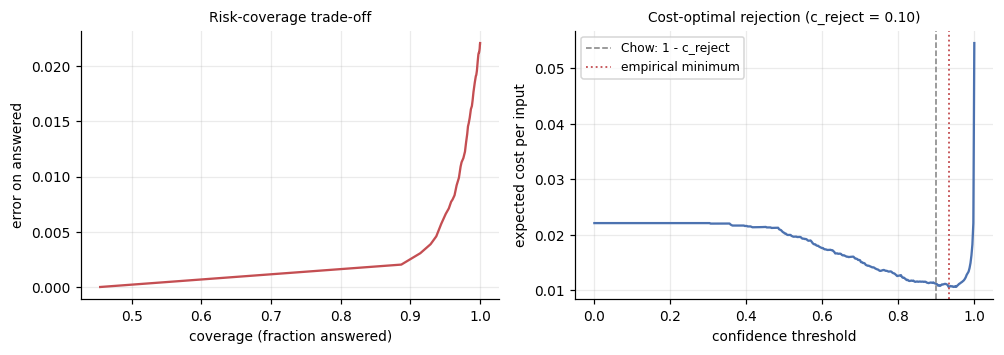

In [38]:
# [complete] 7.5c -- a reject option, and the metric that justifies it.
# Deployment premise: a wrong digit costs 1; abstaining and asking a human costs c_reject < 1.
# Then the expected cost of answering with confidence p is (1 - p), so answering beats abstaining
# exactly when 1 - p < c_reject, i.e. p > 1 - c_reject. That is Chow's rule -- the threshold is
# not a hyperparameter to tune, it follows from the cost ratio.
def selective_risk(probs: np.ndarray, y: np.ndarray, thresholds: Sequence[float]) -> List[Dict]:
    conf = probs.max(axis=1)
    correct = probs.argmax(axis=1) == y
    out = []
    for t in thresholds:
        accept = conf >= t
        n_acc = int(accept.sum())
        out.append({
            "threshold": t,
            "coverage": n_acc / len(y),
            "accuracy_on_accepted": float(correct[accept].mean()) if n_acc else float("nan"),
            "errors_served": int((~correct & accept).sum()),
            "abstentions": int((~accept).sum()),
        })
    return out

THRESHOLDS = [0.0, 0.5, 0.9, 0.95, 0.99, 0.999]
rows = selective_risk(probs_test, y_test, THRESHOLDS)

print("%-11s %-11s %-14s %-15s %s" %
      ("threshold", "coverage", "acc accepted", "errors served", "abstentions"))
for r in rows:
    print("%-11.3f %-11.4f %-14.4f %-15d %d"
          % (r["threshold"], r["coverage"], r["accuracy_on_accepted"],
             r["errors_served"], r["abstentions"]))

C_REJECT = 0.1                      # abstaining costs a tenth of a wrong answer
chow_threshold = 1.0 - C_REJECT

def expected_cost(probs: np.ndarray, y: np.ndarray, t: float, c_reject: float) -> float:
    """Mean cost per input: 1 per served error, c_reject per abstention."""
    conf = probs.max(axis=1)
    correct = probs.argmax(axis=1) == y
    accept = conf >= t
    return float((np.sum(~correct & accept) * 1.0 + np.sum(~accept) * c_reject) / len(y))

grid = np.linspace(0.0, 0.9999, 400)
costs = np.array([expected_cost(probs_test, y_test, t, C_REJECT) for t in grid])
t_star = float(grid[int(np.argmin(costs))])

print("\nwith c_reject = %.2f:" % C_REJECT)
print("  cost with no rejection  %.5f" % expected_cost(probs_test, y_test, 0.0, C_REJECT))
print("  cost at Chow threshold  %.5f  (t = %.2f, derived)" % (
    expected_cost(probs_test, y_test, chow_threshold, C_REJECT), chow_threshold))
print("  best empirical          %.5f  (t = %.4f, searched)" % (costs.min(), t_star))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))
cov = [r["coverage"] for r in selective_risk(probs_test, y_test, np.linspace(0, 0.9999, 60))]
err = [1 - r["accuracy_on_accepted"] for r in selective_risk(probs_test, y_test, np.linspace(0, 0.9999, 60))]
axes[0].plot(cov, err, "-", color="#C44E52")
axes[0].set_xlabel("coverage (fraction answered)"); axes[0].set_ylabel("error on answered")
axes[0].set_title("Risk-coverage trade-off", fontsize=9)

axes[1].plot(grid, costs, color="#4C72B0")
axes[1].axvline(chow_threshold, ls="--", color="grey", lw=1, label="Chow: 1 - c_reject")
axes[1].axvline(t_star, ls=":", color="#C44E52", lw=1.2, label="empirical minimum")
axes[1].set_xlabel("confidence threshold"); axes[1].set_ylabel("expected cost per input")
axes[1].set_title("Cost-optimal rejection (c_reject = %.2f)" % C_REJECT, fontsize=9)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7.6 Expected behaviour and the ideal comparison

Test error read against non-learned baselines, ablation-grid floors, and published benchmarks.
See the report for the analysis.

---
## 8. The deployment interface (Criterion A)

Criterion A asks for the input/output specification of **both** phases, and deployment differs from
training in ways that are easy to leave implicit and get caught on: one image rather than a batch,
`uint8` rather than normalised floats, no label, and a caller who needs a decision rather than a
vector of logits.

This wrapper is the executable form of the §1.2 contract. It validates its input rather than
reshaping whatever it is handed — a silent `reshape` is how a deployed model ends up classifying
transposed images at chance and nobody noticing.

In [39]:
# [complete] The deployment wrapper: single image in, decision out.
class DigitClassifier:
    """Serving interface for a trained MLP. Implements the contract declared in 1.2."""

    def __init__(self, model: MLP, reject_below: Optional[float] = None):
        self.model = model
        self.reject_below = reject_below      # None disables abstention; see 7.5c for the value

    @staticmethod
    def validate(image: np.ndarray) -> None:
        """Reject anything that does not match the declared input contract, loudly."""
        if not isinstance(image, np.ndarray):
            raise TypeError("expected a numpy array, got " + type(image).__name__)
        if image.shape != IMAGE_SHAPE:
            raise ValueError("expected shape %s, got %s" % (IMAGE_SHAPE, image.shape))
        if image.dtype != np.uint8:
            raise TypeError("expected dtype uint8 in 0..255, got " + str(image.dtype))

    def predict(self, image: np.ndarray) -> Dict[str, object]:
        """One 28x28 uint8 image -> label, confidence, and the full distribution."""
        self.validate(image)
        x = preprocess(image[None, ...])                    # the same transform as training: /255
        probs = softmax(self.model.forward(x, training=False))[0]
        label = int(probs.argmax())
        confidence = float(probs[label])

        if self.reject_below is not None and confidence < self.reject_below:
            return {"label": None, "confidence": confidence, "probs": probs, "abstained": True}
        return {"label": label, "confidence": confidence, "probs": probs, "abstained": False}


classifier = DigitClassifier(model, reject_below=0.90)

print("Six test images through the deployment path:")
for i in range(6):
    out = classifier.predict(raw_test_images[i])
    verdict = "ABSTAIN" if out["abstained"] else ("label %d" % out["label"])
    print("  true %d -> %-9s confidence %.4f" % (y_test[i], verdict, out["confidence"]))

print("\nInput validation (each of these should raise):")
for bad, why in ((np.zeros((28, 28), dtype=np.float64), "float64 instead of uint8"),
                 (np.zeros((32, 32), dtype=np.uint8), "wrong shape"),
                 ([[0] * 28] * 28, "a list, not an array")):
    try:
        classifier.predict(bad)
        print("  %-34s NOT REJECTED -- the contract is not being enforced" % why)
    except (TypeError, ValueError) as e:
        print("  %-34s rejected: %s" % (why, e))

Six test images through the deployment path:
  true 7 -> label 7   confidence 0.9997
  true 2 -> label 2   confidence 1.0000
  true 1 -> label 1   confidence 0.9994
  true 0 -> label 0   confidence 1.0000
  true 4 -> label 4   confidence 0.9996
  true 1 -> label 1   confidence 0.9996

Input validation (each of these should raise):
  float64 instead of uint8           rejected: expected dtype uint8 in 0..255, got float64
  wrong shape                        rejected: expected shape (28, 28), got (32, 32)
  a list, not an array               rejected: expected a numpy array, got list


In [40]:
# [complete] The failure mode 1.2 warns about: input that is not a digit at all.
noise = make_rng(5).integers(0, 256, size=IMAGE_SHAPE, dtype=np.uint8)
blank = np.zeros(IMAGE_SHAPE, dtype=np.uint8)
inverted = 255 - raw_test_images[0]      # white ink on black: valid dtype, wrong convention

for name, img in (("uniform noise", noise), ("blank image", blank), ("inverted digit", inverted)):
    out = DigitClassifier(model).predict(img)     # no reject threshold, to see the raw claim
    print("%-16s -> label %d with confidence %.4f" % (name, out["label"], out["confidence"]))

uniform noise    -> label 3 with confidence 0.4896
blank image      -> label 5 with confidence 0.2283
inverted digit   -> label 5 with confidence 0.9964


---
## 9. Results, discussion, reflection

| | |
|---|---|
| Test accuracy | 97.79% (221 errors / 10,000), macro F1 0.9778 |
| Baselines | chance 10.0%, majority class 12.05%, hand-designed ink rules 19.70% |
| Seed variance | 0.9746 ± 0.0021 (validation, 3 seeds) |

Full results, discussion and reflection are in the accompanying report.

---
## 10. Implementation log

Challenges and solutions, use of AI tools, knowledge gaps, and the milestone record are in the
accompanying report/journal.

---

## 11. Test It Yourself

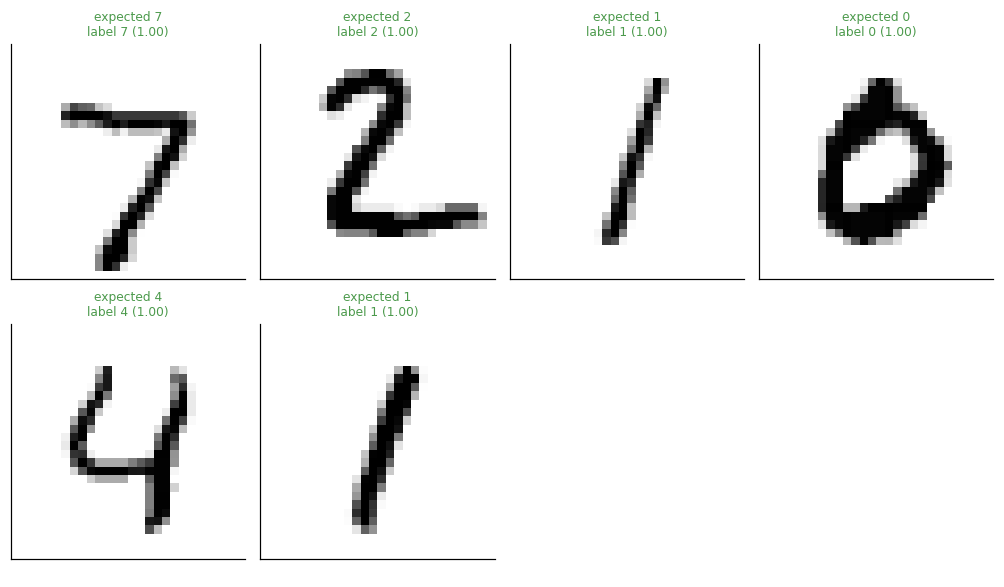

found 5 image(s) in my_digits: ['3.png', '33.jpg', '9.jpg', 'images.png', 'nine.jpg']


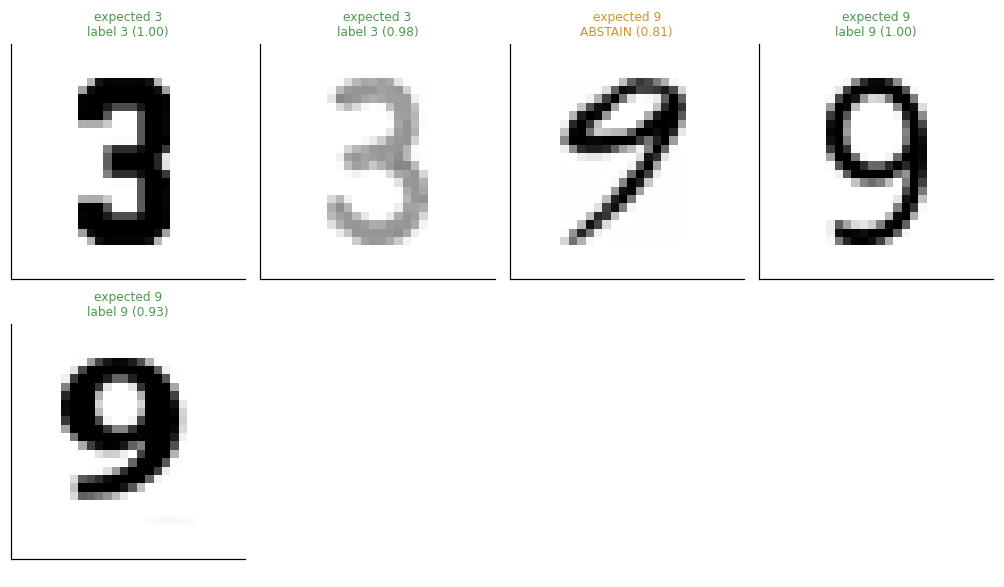

In [41]:
# [Test It Yourself] Visualise several predictions at once -- self-contained, doesn't depend
# on any earlier cell having already run.
from pathlib import Path
from PIL import Image

def mnist_normalize(path):
    """Load an arbitrary image file and reshape it into MNIST's exact convention:
    (28,28) uint8, white ink on black, digit cropped and centred like the training data."""
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.float64)
    arr = 255 - arr if arr.mean() > 127 else arr        # crude auto-polarity
    ys, xs = np.where(arr > 30)
    arr = arr[ys.min():ys.max()+1, xs.min():xs.max()+1]  # crop to the ink's bounding box

    h, w = arr.shape
    scale = 20.0 / max(h, w)                             # fit the longer side into 20
    new_h, new_w = max(1, round(h * scale)), max(1, round(w * scale))
    digit = Image.fromarray(arr.astype(np.uint8)).resize((new_w, new_h))

    canvas = Image.new("L", (28, 28), color=0)
    off_x, off_y = (28 - new_w) // 2, (28 - new_h) // 2
    canvas.paste(digit, (off_x, off_y))
    return np.array(canvas, dtype=np.uint8)


def show_predictions(images, expected=None, cols=4, figsize_per=(2.3, 2.7)):
    """images   : list of (28, 28) uint8 arrays (MNIST-format: white ink on black).
    expected : optional list, same length, of the digit you believe each image shows.
    """
    n = len(images)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per[0], rows * figsize_per[1]))
    axes = np.atleast_2d(axes)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.set_xticks([]); ax.set_yticks([])
        if i >= n:
            ax.axis("off")
            continue

        img = images[i]
        out = classifier.predict(img)
        exp = expected[i] if expected is not None else None

        if out["abstained"]:
            verdict, color = "ABSTAIN", "#C9962C"
        elif exp is not None and out["label"] == exp:
            verdict, color = "label %d" % out["label"], "#4C9A4C"
        elif exp is not None:
            verdict, color = "label %d" % out["label"], "#C44E52"
        else:
            verdict, color = "label %d" % out["label"], "#4C72B0"

        ax.imshow(img, cmap="gray_r", vmin=0, vmax=255)
        title = ("expected %d\n" % exp if exp is not None else "") + \
                "%s (%.2f)" % (verdict, out["confidence"])
        ax.set_title(title, fontsize=8, color=color)

    plt.tight_layout(); plt.show()


# --- Real test images (known-correct, for reference) ---
idx = [0, 1, 2, 3, 4, 5]
show_predictions([raw_test_images[i] for i in idx],
                 expected=[int(y_test[i]) for i in idx])

# --- Your own images: every file in my_digits/, discovered automatically ---
MY_DIGITS_DIR = Path("my_digits")
IMG_EXTS = {".png", ".jpg", ".jpeg"}

my_files = sorted(p for p in MY_DIGITS_DIR.iterdir() if p.suffix.lower() in IMG_EXTS)
print("found %d image(s) in %s: %s" % (len(my_files), MY_DIGITS_DIR, [p.name for p in my_files]))

# Optional: the digit you believe each file shows, for colour-coded correct/wrong. Any file not
# listed here still gets tested and shown -- just without a correctness judgement (blue, not
# green/red) -- so dropping a new image into my_digits/ works with zero code changes.
known_labels = {"9.jpg": 9, "nine.jpg": 9, "images.png": 9, "3.png": 3, "33.jpg": 3}

my_images = [mnist_normalize(str(p)) for p in my_files]
my_expected = [known_labels.get(p.name) for p in my_files]

show_predictions(my_images, expected=my_expected)
